<a href="https://colab.research.google.com/github/wan-huiyan/ShinyCICD-min/blob/master/elena_schuh_ci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BigQuery tables, queries

### dim_calendar: dates and calendar covariates



```
CREATE OR REPLACE TABLE `swordfish-2015.causal_impact.dim_calendar` AS

WITH date_spine AS (
  SELECT day AS date
  FROM UNNEST(GENERATE_DATE_ARRAY(DATE '2024-01-01', DATE '2026-12-31')) AS day
),

-- Centralizing all "Floating" date logic here
holiday_logic AS (
  SELECT
    date,
    EXTRACT(YEAR FROM date) AS year,
    -- Easter Sunday calculation
    DATE_ADD(DATE(EXTRACT(YEAR FROM date), 3, 22),
             INTERVAL (MOD(19 * MOD(EXTRACT(YEAR FROM date), 19) + 24, 30)
                     + MOD(2 * MOD(EXTRACT(YEAR FROM date), 4) + 4 * MOD(EXTRACT(YEAR FROM date), 7)
                     + 6 * MOD(19 * MOD(EXTRACT(YEAR FROM date), 19) + 24, 30) + 5, 7)) DAY) AS easter_sunday,
    -- Black Friday calculation
    DATE_ADD(DATE(EXTRACT(YEAR FROM date), 11, 1), INTERVAL (
      CASE
        WHEN EXTRACT(DAYOFWEEK FROM DATE(EXTRACT(YEAR FROM date), 11, 1)) <= 5
        THEN 5 - EXTRACT(DAYOFWEEK FROM DATE(EXTRACT(YEAR FROM date), 11, 1)) + 21
        ELSE 5 - EXTRACT(DAYOFWEEK FROM DATE(EXTRACT(YEAR FROM date), 11, 1)) + 28
      END
    ) DAY) AS black_friday
  FROM date_spine
),

retail_events AS (
  SELECT
    h.date,
    h.black_friday,
    h.easter_sunday,
    CASE
      WHEN EXTRACT(MONTH FROM h.date) = 1 AND EXTRACT(DAY FROM h.date) = 1 THEN 'New Year'
      WHEN EXTRACT(MONTH FROM h.date) = 2 AND EXTRACT(DAY FROM h.date) = 14 THEN 'Valentines Day'
      WHEN EXTRACT(MONTH FROM h.date) = 12 AND EXTRACT(DAY FROM h.date) = 25 THEN 'Christmas Day'
      WHEN EXTRACT(MONTH FROM h.date) = 12 AND EXTRACT(DAY FROM h.date) = 26 THEN 'Boxing Day'
      WHEN h.date = DATE_SUB(h.easter_sunday, INTERVAL 2 DAY) THEN 'Good Friday'
      WHEN h.date = DATE_ADD(h.easter_sunday, INTERVAL 1 DAY) THEN 'Easter Monday'
      WHEN h.date = DATE_SUB(h.easter_sunday, INTERVAL 21 DAY) THEN 'Mothers Day'
      WHEN EXTRACT(MONTH FROM h.date) = 6 AND EXTRACT(DAYOFWEEK FROM h.date) = 1 AND EXTRACT(DAY FROM h.date) BETWEEN 15 AND 21 THEN 'Fathers Day'
      WHEN h.date = h.black_friday THEN 'Black Friday'
      WHEN h.date = DATE_ADD(h.black_friday, INTERVAL 3 DAY) THEN 'Cyber Monday'
      -- Standard Bank Holidays
      WHEN EXTRACT(MONTH FROM h.date) = 5 AND EXTRACT(DAYOFWEEK FROM h.date) = 2 AND EXTRACT(DAY FROM h.date) <= 7 THEN 'Early May Bank Holiday'
      WHEN EXTRACT(MONTH FROM h.date) = 5 AND EXTRACT(DAYOFWEEK FROM h.date) = 2 AND EXTRACT(DAY FROM h.date) >= 25 THEN 'Spring Bank Holiday'
      WHEN EXTRACT(MONTH FROM h.date) = 8 AND EXTRACT(DAYOFWEEK FROM h.date) = 2 AND EXTRACT(DAY FROM h.date) >= 25 THEN 'August Bank Holiday'
    END AS holiday_name
  FROM holiday_logic h
)

SELECT
  re.date,
  EXTRACT(DAYOFWEEK FROM re.date) AS day_of_week,
  CASE WHEN EXTRACT(DAYOFWEEK FROM re.date) IN (1, 7) THEN 1 ELSE 0 END AS is_weekend,
  CASE WHEN EXTRACT(DAY FROM re.date) IN (25, 26, 27, 28, 29, 30, 31, 1, 2, 3) THEN 1 ELSE 0 END AS payday_window_flag,
  re.holiday_name,
  
  -- Corrected KCP logic using local column references
  CASE
    -- 1. Black Friday window (Starts 7 days before BF, ends Cyber Monday)
    WHEN re.date BETWEEN DATE_SUB(re.black_friday, INTERVAL 7 DAY) AND DATE_ADD(re.black_friday, INTERVAL 3 DAY) THEN 1
    
    -- 2. Peak Christmas (Dec 10th to Jan 2nd)
    WHEN (EXTRACT(MONTH FROM re.date) = 12 AND EXTRACT(DAY FROM re.date) >= 10)
      OR (EXTRACT(MONTH FROM re.date) = 1 AND EXTRACT(DAY FROM re.date) <= 2) THEN 1
    
    -- 3. Lead up to Mother's/Father's Day (3 days prior + the day itself)
    WHEN re.holiday_name IN ('Mothers Day', 'Fathers Day')
      OR EXISTS(SELECT 1 FROM retail_events e2 WHERE e2.holiday_name IN ('Mothers Day', 'Fathers Day') AND re.date BETWEEN DATE_SUB(e2.date, INTERVAL 3 DAY) AND e2.date) THEN 1
    
    -- 4. Any other specific holiday/bank holiday
    WHEN re.holiday_name IS NOT NULL THEN 1
    
    ELSE 0
  END AS kcp_period_flag,

  -- Corrected KCP logic using local column references
  CASE
    -- 1. Black Friday window (Starts 7 days before BF, ends Cyber Monday)
    WHEN re.date BETWEEN DATE_SUB(re.black_friday, INTERVAL 7 DAY) AND DATE_ADD(re.black_friday, INTERVAL 3 DAY) THEN 1
    
    -- 2. Peak Christmas (Dec 10th to Jan 2nd)
    WHEN (EXTRACT(MONTH FROM re.date) = 12 AND EXTRACT(DAY FROM re.date) >= 10)
      OR (EXTRACT(MONTH FROM re.date) = 1 AND EXTRACT(DAY FROM re.date) <= 2) THEN 1
    
    ELSE 0
  END AS yearend_period_flag

FROM retail_events re
ORDER BY re.date;
```



### features: GA4 data summary, features





```
CREATE OR REPLACE TABLE `swordfish-2015.causal_impact.features` AS

WITH base AS (
  SELECT
    PARSE_DATE('%Y%m%d', event_date) AS date,
    event_name,
    --user_id,
    --user_pseudo_id,

    CONCAT(user_pseudo_id, CAST((SELECT value.int_value FROM UNNEST(event_params) WHERE key = 'ga_session_id') AS STRING)) as session_id,

    -- Purchase-level values
    ecommerce.transaction_id AS transaction_id,
    ecommerce.purchase_revenue AS purchase_revenue,

    -- Session traffic source fields
    LOWER(IF(session_traffic_source_last_click.google_ads_campaign.account_name IS NOT NULL, 'google',session_traffic_source_last_click.manual_campaign.source)) AS traffic_source,
    LOWER(IF(session_traffic_source_last_click.google_ads_campaign.account_name IS NOT NULL, 'cpc', session_traffic_source_last_click.manual_campaign.medium)) AS traffic_medium,
    LOWER(IF(session_traffic_source_last_click.google_ads_campaign.account_name IS NOT NULL, session_traffic_source_last_click.google_ads_campaign.campaign_name, session_traffic_source_last_click.manual_campaign.campaign_name)) AS traffic_campaign

  FROM `swordfish-2015.analytics_298003350.events_*`
  WHERE _TABLE_SUFFIX BETWEEN '20251001' AND '20260315'
  and privacy_info.analytics_storage = 'Yes'
  and (event_name = "purchase" or event_name = "session_start")
),

events_enriched AS (
  SELECT *,

    COALESCE(traffic_source, '(direct)') AS session_source,
    COALESCE(traffic_medium, '(none)') AS session_medium,
    CASE
      WHEN REGEXP_CONTAINS(LOWER(COALESCE(traffic_medium, '')), 'paid|cpc|ppc|display|adv|affiliate|redbrain|awin|aw') THEN 'paid'
      WHEN REGEXP_CONTAINS(LOWER(COALESCE(traffic_source, '')), 'paid|cpc|ppc|display|adv|affiliate|redbrain|awin|aw') THEN 'paid'
      WHEN REGEXP_CONTAINS(LOWER(COALESCE(traffic_campaign, '')), 'paid|cpc|ppc|display|adv|affiliate|redbrain|awin|aw') THEN 'paid'
      ELSE 'organic'
    END AS channel_group

  FROM base
),

daily_totals AS (
  SELECT
    date,

    -- Revenue / transactions
    ROUND(SUM(CASE WHEN event_name = 'purchase' THEN COALESCE(purchase_revenue, 0) ELSE 0 END), 2) AS revenue,
    COUNT(DISTINCT CASE WHEN event_name = 'purchase' THEN transaction_id END) AS transactions,

    -- Users
    -- COUNT(DISTINCT user_pseudo_id) AS users,

    -- Sessions
    COUNT(DISTINCT session_id) AS sessions

  FROM events_enriched
  GROUP BY 1
),

daily_channel AS (
  SELECT
    date,

    COUNT(DISTINCT CASE
      WHEN channel_group = 'paid'
      THEN session_id
    END) AS paid_sessions,

    COUNT(DISTINCT CASE
      WHEN channel_group = 'organic'
      THEN session_id
    END) AS organic_sessions,

    SUM(CASE
      WHEN event_name = 'purchase' AND channel_group = 'paid'
      THEN COALESCE(purchase_revenue, 0) ELSE 0
    END) AS paid_revenue,

    SUM(CASE
      WHEN event_name = 'purchase' AND channel_group = 'organic'
      THEN COALESCE(purchase_revenue, 0) ELSE 0
    END) AS organic_revenue

  FROM events_enriched
  GROUP BY 1
)

SELECT
  t.date,

  -- Outcome
  t.revenue,
  t.transactions,
  t.sessions,
  ROUND(SAFE_DIVIDE(t.transactions, t.sessions), 2) AS conversion_rate,
  ROUND(SAFE_DIVIDE(t.revenue, t.transactions), 2) AS aov,

  -- Treatment
  CASE
    WHEN t.date BETWEEN DATE '2026-02-27' AND DATE '2026-03-02' THEN 1
    ELSE 0
  END AS treatment_flag,

  -- Known confounders / event flags
  CASE
    WHEN t.date BETWEEN DATE '2025-12-14' AND DATE '2026-02-01' THEN 1
    ELSE 0
  END AS winter_sale_flag,

  CASE
    WHEN t.date BETWEEN DATE '2026-01-16' AND DATE '2026-01-25' THEN 1
    ELSE 0
  END AS student_20_flag,

  CASE
    WHEN t.date >= DATE '2026-01-11' THEN 1
    ELSE 0
  END AS loyalty_discount_restriction_post_flag,

  -- Channel diagnostics
  c.paid_sessions,
  c.organic_sessions,

  c.paid_revenue,
  c.organic_revenue

FROM daily_totals t
LEFT JOIN daily_channel c
  USING (date)
ORDER BY t.date;
```



# Config

In [ ]:
# Install the necessary libraries for Colab
!pip install tfcausalimpact db-dtypes google-cloud-bigquery

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import io
import json
import hashlib
import os
import re
import shutil
import socket
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_probability as tfp
from causalimpact import CausalImpact
from google.colab import auth
from google.cloud import bigquery
import google.auth
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload, MediaIoBaseDownload
import ipywidgets as widgets
from IPython.display import display
from datetime import date as _date

# Auth

In [ ]:
auth.authenticate_user()
print('Authenticated successfully')

Authenticated successfully


# Data extraction

in the causal_impact dataset, we have:
- a table "dim_calendar", that contains flags for calendar covariates (payday, key consumption period, ...)
- a table "features_v1" with features and other covariates

In [ ]:
# ----------------------------
# User config
# ----------------------------
PROJECT_ID = "swordfish-2015"
#"emea-data-training"
#"swordfish-2015"
DATASET_ID = "causal_impact"
TABLE_NAME = "features"
TABLE_CALENDAR = "dim_calendar" # this contains calendar covariates like is_weekend, is payday(s), is kcp (key consumption period)

MAIN_TABLE = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_NAME}"
CALENDAR_TABLE = f"{PROJECT_ID}.{DATASET_ID}.{TABLE_CALENDAR}"

DATE_COL = "date"
TARGET_KPI = "revenue"

INTERVENTION_START = pd.Timestamp("2026-02-27")
INTERVENTION_END = pd.Timestamp("2026-03-02")

COVARIATES = [
    "sessions",
    "winter_sale_flag",
    "student_20_flag",
    "loyalty_discount_restriction_post_flag",
    "is_weekend",
    "payday_window_flag",
    "kcp_period_flag"
]

BINARY_COVARIATES = [
    "winter_sale_flag",
    "student_20_flag",
    "is_weekend",
    "payday_window_flag",
    "loyalty_discount_restriction_post_flag",
    "kcp_period_flag"
]

# ----------------------------
# Experiment tracking config
# ----------------------------
DRIVE_FOLDER_ID = "19-xUgGBAqiBfPuEs2tBu1pz-4rgM6Jqi"
EXPERIMENT_NAME = "uk_revenue_delivery_promo"
PIPELINE_VERSION = "2026-03-17_v1"
EXPERIMENT_NOTE = ""  # Optional free-text note for this run


In [ ]:
client = bigquery.Client(project=PROJECT_ID)

query = f"""
SELECT t.*, c.* except(date)
FROM `{MAIN_TABLE}` t
LEFT JOIN `{CALENDAR_TABLE}` c
  USING (date)
"""

df = client.query(query).to_dataframe()
print(f"Rows returned: {len(df):,}")
df.head()

Rows returned: 531


,date,revenue,transactions,sessions,conversion_rate,aov,treatment_flag,winter_sale_flag,student_20_flag,loyalty_discount_restriction_post_flag,paid_sessions,organic_sessions,paid_revenue,organic_revenue,day_of_week,is_weekend,payday_window_flag,holiday_name,kcp_period_flag,yearend_period_flag
0,2024-10-01,475608.14,5546,257966,0.02,85.76,0,0,0,0,110948,147020,262525.96,213082.18,3,0,1,None,0,0
1,2024-10-02,429152.66,5293,241855,0.02,81.08,0,0,0,0,104740,137117,231353.71,197798.95,4,0,1,None,0,0
2,2024-10-03,377841.37,4831,239110,0.02,78.21,0,0,0,0,99317,139793,205809.64,172031.73,5,0,1,None,0,0
3,2024-10-04,381108.06,4766,236711,0.02,79.96,0,0,0,0,99314,137399,213449.27,167658.79,6,0,0,None,0,0
4,2024-10-05,414495.73,5310,268934,0.02,78.06,0,0,0,0,116408,152527,225707.43,188788.30,7,1,0,None,0,0


# Data Preprocessing

Data needs to be prepared for the `CausalImpact` library. This involves:
1.  Converting the date column to datetime objects
2.  Handling missing values.
3.  Selecting the target KPI (`revenue`) and any covariates.


In [ ]:
def validate_source_table(df: pd.DataFrame, date_col: str, target_col: str) -> None:
    required_cols = {date_col, target_col}
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    if df.empty:
        raise ValueError("The source query returned 0 rows.")

    if df[date_col].isnull().any():
        raise ValueError(f"Column '{date_col}' contains nulls.")

    if df.duplicated(subset=[date_col]).any():
        dupes = df[df.duplicated(subset=[date_col], keep=False)].sort_values(date_col)
        raise ValueError(
            "The table has duplicate dates. CausalImpact needs one row per day. "
            f"Problem dates include: {dupes[date_col].astype(str).head(10).tolist()}"
        )

    if target_col not in df.columns:
        raise ValueError(f"Target KPI '{target_col}' not found in source table.")

validate_source_table(df, DATE_COL, TARGET_KPI)

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

print("Date range:", df[DATE_COL].min().date(), "to", df[DATE_COL].max().date())
print("Columns available:", list(df.columns))

Date range: 2024-10-01 to 2026-03-15
Columns available: ['date', 'revenue', 'transactions', 'sessions', 'conversion_rate', 'aov', 'treatment_flag', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'paid_sessions', 'organic_sessions', 'paid_revenue', 'organic_revenue', 'day_of_week', 'is_weekend', 'payday_window_flag', 'holiday_name', 'kcp_period_flag', 'yearend_period_flag']


## Define modeling windows
Separates **headline promo uplift** from **post-period diagnostics**.

- **Training / pre-period:** all days before 27 Feb 2026
- **Evaluation horizon:** 27 Feb 2026 onward
- **Headline business answer:** cumulative incremental effect **during 27 Feb–2 Mar only**
- **Secondary diagnostic:** any residual effect **after 2 Mar**


In [ ]:
_d_min = data_final.index.min().date()
_d_max = data_final.index.max().date()
_fmt = lambda d: pd.Timestamp(d).strftime("%Y-%m-%d")

_dp = {"description_width": "140px"}
_w_pre_start = widgets.DatePicker(description="Pre-period start", value=_d_min, style=_dp)
_w_int_start = widgets.DatePicker(description="Intervention start", value=INTERVENTION_START.date(), style=_dp)
_w_int_end   = widgets.DatePicker(description="Intervention end", value=INTERVENTION_END.date(), style=_dp)
_w_status = widgets.HTML()
_w_confirm = widgets.Button(description="Confirm windows")

def _validate():
    pre_s, int_s, int_e = _w_pre_start.value, _w_int_start.value, _w_int_end.value
    checks = [
        (pre_s < _d_min or pre_s > _d_max, f"Pre-period start outside dataset [{_d_min}, {_d_max}]."),
        (int_s <= pre_s,                    "Intervention start must be after pre-period start."),
        (int_e < int_s,                     "Intervention end must be >= intervention start."),
        (int_e > _d_max,                    f"Intervention end is after dataset ends ({_d_max})."),
    ]
    errors = [msg for flag, msg in checks if flag]
    return errors

def _build_windows():
    """Derive all windows from the 3 source dates."""
    pre_s, int_s, int_e = _w_pre_start.value, _w_int_start.value, _w_int_end.value
    pre_end = int_s - pd.Timedelta(days=1)
    pre_days = (pd.Timestamp(pre_end) - pd.Timestamp(pre_s)).days + 1
    return dict(
        pre_period       = [_fmt(pre_s), _fmt(pre_end)],
        promo_window     = [_fmt(int_s), _fmt(int_e)],
        full_post_period = [_fmt(int_s), _fmt(_d_max)],
        pre_days         = pre_days,
    )

def _render():
    errors = _validate()
    if errors:
        _w_status.value = f"<pre style='color:red'>{'  '.join(errors)}</pre>"
        return
    w = _build_windows()
    warn = "<b>Warning:</b> pre-period is short for a causal design.<br>" if w["pre_days"] < 35 else ""
    _w_status.value = (
        f"<pre>{warn}"
        f"Pre period:       {w['pre_period']}  ({w['pre_days']} days)\n"
        f"Promo window:     {w['promo_window']}\n"
        f"Full post-period: {w['full_post_period']}</pre>"
    )

def _on_confirm(_):
    global INTERVENTION_START, INTERVENTION_END, pre_period, promo_window, full_post_period
    if _validate():
        _render()
        return
    INTERVENTION_START = pd.Timestamp(_w_int_start.value)
    INTERVENTION_END   = pd.Timestamp(_w_int_end.value)
    w = _build_windows()
    pre_period       = w["pre_period"]
    promo_window     = w["promo_window"]
    full_post_period = w["full_post_period"]
    _render()

for _w in [_w_pre_start, _w_int_start, _w_int_end]:
    _w.observe(lambda _: _render(), names="value")
_w_confirm.on_click(_on_confirm)

display(widgets.VBox([_w_pre_start, _w_int_start, _w_int_end, _w_confirm, _w_status]))
_on_confirm(None)

## Covariate selection

In [ ]:
import ipywidgets as widgets
from IPython.display import display

available = [c for c in COVARIATES if c in df.columns]
missing = [c for c in COVARIATES if c not in df.columns]
candidates = [c for c in df.columns if c not in {DATE_COL, TARGET_KPI}]

if missing:
    print("Default covariates not in table (ignored):", missing)

cbs = {
    col: widgets.Checkbox(value=col in available, description=col, indent=False)
    for col in candidates
}

confirm_btn = widgets.Button(description="Confirm selection")
status = widgets.HTML()

def _on_confirm(_):
    global COVARIATES
    COVARIATES = [col for col, cb in cbs.items() if cb.value]
    status.value = f"Locked {len(COVARIATES)} covariates: {COVARIATES}"

confirm_btn.on_click(_on_confirm)
display(widgets.VBox([*cbs.values(), confirm_btn, status]))

COVARIATES = available.copy()
print("Selected covariates:", COVARIATES if COVARIATES else "None (univariate model)")

Selected covariates: ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag', 'yearend_period_flag']


## Build the modeling dataset

produces a diagnostic report card for each covariate before modelling. For every column in COVARIATES, it checks:

Whether the column actually exists in the dataframe
Its dtype
% of missing values (full dataset and pre-period only)
Number of unique values in the pre-period
Standard deviation in the pre-period
Whether it's constant in the pre-period (useless for the model)
The result is a sorted dataframe that surfaces problems — missing columns first, then constant ones, then high-missingness ones.



In [ ]:
def audit_covariates(
    df: pd.DataFrame,
    date_col: str,
    target_col: str,
    covariates: list[str],
    window_start: pd.Timestamp,
    window_end: pd.Timestamp,
) -> pd.DataFrame:
    mask = (df[date_col] >= window_start) & (df[date_col] <= window_end)
    windowed = df.loc[mask, covariates]
    all_ = df[covariates]

    audit = pd.DataFrame({
        "covariate": covariates,
        "exists": [c in df.columns for c in covariates],
        "dtype": [str(df[c].dtype) for c in covariates],
        "missing_pct_all": all_.isna().mean().values,
        "missing_pct_pre": windowed.isna().mean().values,
        "n_unique_pre": windowed.nunique().values,
        "std_pre": windowed.std().values,
        "is_constant_pre": (windowed.nunique() <= 1).values,
        "corr_with_target": [
            windowed[c].corr(df.loc[mask, target_col])
            for c in covariates
        ],
    })
    return audit.sort_values(["is_constant_pre", "missing_pct_pre"], ascending=[True, True])

cov_audit = audit_covariates(
    df,
    DATE_COL,
    TARGET_KPI,
    COVARIATES,
    window_start=pd.Timestamp(pre_period[0]),
    window_end=INTERVENTION_END,
)
display(cov_audit)

,covariate,exists,dtype,missing_pct_all,missing_pct_pre,n_unique_pre,std_pre,is_constant_pre,corr_with_target
0,sessions,True,Int64,0.0,0.0,56,39176.585162,False,0.775145
1,winter_sale_flag,True,Int64,0.0,0.0,2,0.504203,False,0.460404
2,student_20_flag,True,Int64,0.0,0.0,2,0.386459,False,0.123455
3,loyalty_discount_restriction_post_flag,True,Int64,0.0,0.0,2,0.287736,False,-0.669150
4,is_weekend,True,Int64,0.0,0.0,2,0.455842,False,0.131248
5,payday_window_flag,True,Int64,0.0,0.0,2,0.455842,False,0.072804
6,kcp_period_flag,True,Int64,0.0,0.0,2,0.133631,False,-0.173956
7,yearend_period_flag,True,Int64,0.0,0.0,1,0.0,True,NaN


In [ ]:
# Select only usable covariates
usable_covariates = cov_audit.loc[
    (cov_audit["is_constant_pre"] == False) &
    (cov_audit["missing_pct_pre"] < 0.5),
    "covariate"
].tolist()

print("Usable covariates:", usable_covariates)
COVARIATES = usable_covariates

Usable covariates: ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']


In [ ]:
def prepare_model_data(
    df: pd.DataFrame,
    date_col: str,
    target_col: str,
    covariates: list[str],
    binary_covariates: list[str] | None = None,
) -> pd.DataFrame:
    binary_covariates = binary_covariates or []

    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])
    data = data.sort_values(date_col).set_index(date_col)

    keep_cols = [target_col] + covariates
    keep_cols = [c for c in keep_cols if c in data.columns]
    data = data[keep_cols].apply(pd.to_numeric, errors="coerce")

    full_idx = pd.date_range(data.index.min(), data.index.max(), freq="D")
    data = data.reindex(full_idx)

    data[target_col] = data[target_col].fillna(0)

    covar_cols = [c for c in data.columns if c != target_col]
    non_binary = [c for c in covar_cols if c not in binary_covariates]
    binary = [c for c in covar_cols if c in binary_covariates]

    if non_binary:
        data[non_binary] = (
            data[non_binary]
            .interpolate(method="linear", limit_direction="both")
            .bfill()
            .ffill()
            .fillna(0)
        )

    if binary:
        data[binary] = (
            data[binary]
            .fillna(0)
            .clip(0, 1)
            .round()
            .astype(int)
        )

    return data

data_final = prepare_model_data(
    df=df,
    date_col=DATE_COL,
    target_col=TARGET_KPI,
    covariates=COVARIATES,
    binary_covariates=BINARY_COVARIATES,
)

data_final.head()


,revenue,sessions,winter_sale_flag,student_20_flag,loyalty_discount_restriction_post_flag,is_weekend,payday_window_flag,kcp_period_flag
2024-10-01,475608.14,257966.0,0,0,0,0,1,0
2024-10-02,429152.66,241855.0,0,0,0,0,1,0
2024-10-03,377841.37,239110.0,0,0,0,0,1,0
2024-10-04,381108.06,236711.0,0,0,0,0,0,0
2024-10-05,414495.73,268934.0,0,0,0,1,0,0


## Visualize the data

In [ ]:
def plot_target(
    data: pd.DataFrame,
    target_col: str,
    flags: list[str],
    intervention_start: pd.Timestamp,
    intervention_end: pd.Timestamp | None = None,
    window_start: str | None = None,
    window_end: str | None = None,
):
    if window_start or window_end:
        data = data.loc[
            (window_start or data.index.min()):
            (window_end or data.index.max())
        ]

    fig, ax = plt.subplots(figsize=(15, 5))
    ax.plot(data.index, data[target_col], linewidth=2, label=target_col)

    ax.axvline(intervention_start, color="red", linestyle="--", alpha=0.8, label="Intervention start")
    if intervention_end is not None:
        ax.axvline(intervention_end, color="red", linestyle=":", alpha=0.8, label="Intervention end")

    ymin, ymax = ax.get_ylim()
    band_height = (ymax - ymin) * 0.05
    base = ymin

    for i, flag in enumerate(flags):
        if flag not in data.columns:
            continue
        y0 = base + i * band_height
        y1 = y0 + band_height * 0.8
        mask = data[flag].fillna(0).astype(int).values > 0
        ax.fill_between(data.index, y0, y1, where=mask, step="post", alpha=0.35, label=flag)

    ax.set_title(f"{target_col} with promo/event flags")
    ax.legend(loc="upper right", ncol=2)
    plt.show()

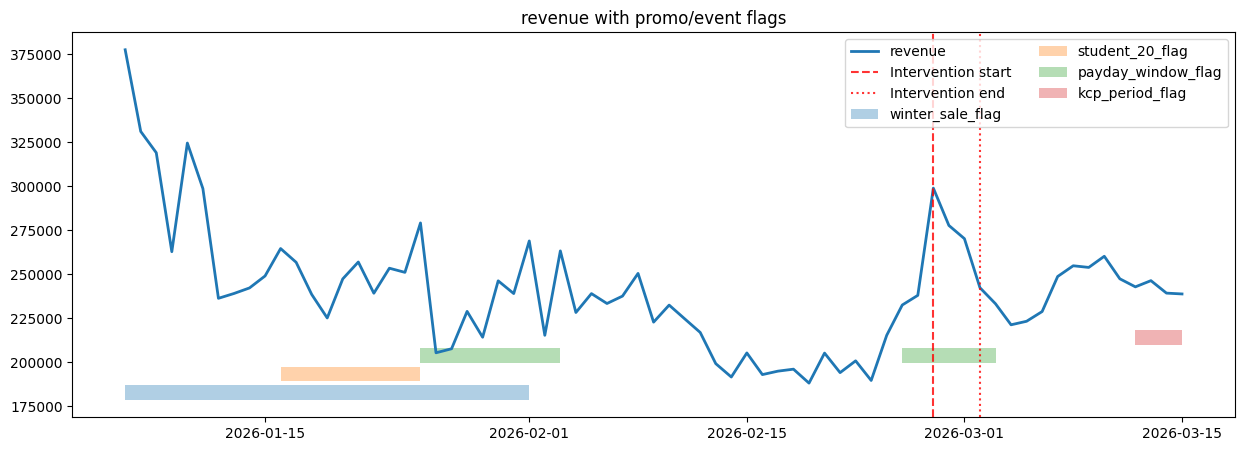

In [ ]:
plot_target(
    data_final,
    TARGET_KPI,
    flags=["winter_sale_flag", "student_20_flag", "payday_window_flag", "kcp_period_flag"],
    intervention_start=INTERVENTION_START,
    intervention_end=INTERVENTION_END,
    window_start=pre_period[0],
    window_end=full_post_period[1],
)

# Run Causal Impact Analysis

this is a **Bayesian structural time series** approach.

This uses tfcausalimpact’s CausalImpact(...) wrapper.
This package is a Python implementation of CausalImpact built on top of TensorFlow Probability, and by default it fits using variational inference.

It is intended to produce the actual counterfactual forecast for the post period and the causal effect

Sanity check
It looks at the pre-intervention data and checks two things:

- No NaNs — if any column has missing values in the pre-period, it raises an error. The BSTS model underneath CausalImpact can't handle NaNs in its design matrix.
- No zero-variance columns — if a column is constant (e.g. a flag that's always 0) during the pre-period, it warns you. A constant column provides no signal and can cause numerical issues in the regression.

In [ ]:
def validate_model_matrix(data: pd.DataFrame, pre_period: list[str]) -> None:
    pre = data.loc[pre_period[0]:pre_period[1]].copy()

    if pre.isna().any().any():
        bad = pre.columns[pre.isna().any()].tolist()
        raise ValueError(f"NaNs found in pre-period columns: {bad}")

    zero_var = [c for c in pre.columns if pre[c].nunique(dropna=True) <= 1]
    if zero_var:
        print("Warning: zero-variance columns in pre-period:", zero_var)

    print("Pre-period rows:", len(pre))
    print("Columns used:", list(data.columns))

validate_model_matrix(data_final[[TARGET_KPI] + COVARIATES], pre_period)
print(data_final.loc[pre_period[0]:pre_period[1], [TARGET_KPI] + COVARIATES].describe().T)

Pre-period rows: 52
Columns used: ['revenue', 'sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']
                                       count           mean           std  \
revenue                                 52.0  238677.225577  38687.133297   
sessions                                52.0  187214.634615  39764.197114   
winter_sale_flag                        52.0       0.519231      0.504505   
student_20_flag                         52.0       0.192308      0.397959   
loyalty_discount_restriction_post_flag  52.0       0.903846      0.297678   
is_weekend                              52.0       0.269231      0.447888   
payday_window_flag                      52.0       0.230769      0.425436   
kcp_period_flag                         52.0       0.019231      0.138675   

                                              min        25%         50%  \
revenue                             

## Experiment tracking and automatic versioning

This section

- It builds a single config payload from the current notebook settings.
- It creates a deterministic config hash.
- It auto-generates version metadata from the authenticated Colab user, the covariates, the time window, and the optional note.
- It loads and updates a registry in Google Drive.
- It refuses to fit if the config changes after the run context has been created, which forces a new tracked version whenever the model setup changes.


In [ ]:
# ============================================
# Experiment tracking, Drive persistence, and version guard
# ============================================

LOCAL_RUNS_ROOT = Path("/content/causal_impact_runs")
LOCAL_RUNS_ROOT.mkdir(parents=True, exist_ok=True)

PRIMARY_COVARIATES = COVARIATES.copy()

PRIMARY_MODEL_ARGS = {
    "nseasons": 7,
    "standardize_data": True,
    "fit_method": "vi",
}

# Validation defaults are defined here so they are included in the experiment hash.
VALIDATION_HORIZON_DAYS = (
    pd.to_datetime(promo_window[1]) - pd.to_datetime(promo_window[0])
).days + 1
MIN_TRAIN_DAYS = 56
ROLLING_STEP_DAYS = 7
MAX_BACKTEST_WINDOWS = 12
VALIDATION_MODEL_ARGS = PRIMARY_MODEL_ARGS.copy()

# Sensitivity bundles are also defined here so a change forces a new tracked version.
SESSIONS_ONLY_COVARIATES = [c for c in ["sessions"] if c in data_final.columns]

SESSIONS_PLUS_CALENDAR_COVARIATES = [
    c for c in ["sessions", "is_weekend", "is_month_end", "payday_window_flag"]
    if c in data_final.columns
]

SESSIONS_PLUS_TRADING_CONTEXT_COVARIATES = [
    c for c in [
        "sessions",
        "winter_sale_flag",
        "student_20_flag",
        "loyalty_discount_restriction_post_flag",
        "kcp_period_flag",
    ]
    if c in data_final.columns
]

SENSITIVITY_SPECS = {
    "sessions_only": SESSIONS_ONLY_COVARIATES,
    "sessions_plus_calendar": SESSIONS_PLUS_CALENDAR_COVARIATES,
    "sessions_plus_trading_context": SESSIONS_PLUS_TRADING_CONTEXT_COVARIATES,
}

RUN_CONTEXT_READY = False
RUN_CONTEXT = None
EXPERIMENT_CONFIG = None
REGISTRY_DF = pd.DataFrame()


def _json_ready(obj):
    if isinstance(obj, (pd.Timestamp, datetime)):
        return obj.isoformat()
    if isinstance(obj, Path):
        return str(obj)
    if isinstance(obj, (np.integer, np.floating, np.bool_)):
        return obj.item()
    if isinstance(obj, pd.Series):
        return {str(k): _json_ready(v) for k, v in obj.to_dict().items()}
    if isinstance(obj, pd.Index):
        return [_json_ready(v) for v in obj.tolist()]
    if isinstance(obj, dict):
        return {str(k): _json_ready(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple, set)):
        return [_json_ready(v) for v in obj]
    if pd.isna(obj) if not isinstance(obj, (str, bytes, dict, list, tuple, set)) else False:
        return None
    return obj


def stable_hash_payload(payload: dict) -> str:
    text = json.dumps(_json_ready(payload), sort_keys=True, separators=(",", ":"))
    return hashlib.sha256(text.encode("utf-8")).hexdigest()


def slugify(text: str, max_len: int = 80) -> str:
    text = re.sub(r"[^a-zA-Z0-9]+", "-", str(text).strip().lower()).strip("-")
    return text[:max_len] or "na"


def get_authenticated_user_info() -> dict:
    info = {"email": None, "name": None}

    try:
        creds, _ = google.auth.default(scopes=[
            "https://www.googleapis.com/auth/drive",
            "https://www.googleapis.com/auth/userinfo.email",
            "https://www.googleapis.com/auth/userinfo.profile",
        ])
        oauth2_service = build("oauth2", "v2", credentials=creds, cache_discovery=False)
        profile = oauth2_service.userinfo().get().execute()
        info["email"] = profile.get("email")
        info["name"] = profile.get("name") or profile.get("given_name")
    except Exception as e:
        info["userinfo_error"] = str(e)

    if not info.get("email"):
        try:
            email = subprocess.check_output(
                ["bash", "-lc", "gcloud config get-value account 2>/dev/null"],
                text=True,
            ).strip()
            if email and email != "(unset)":
                info["email"] = email
        except Exception as e:
            info["gcloud_error"] = str(e)

    if not info.get("name") and info.get("email"):
        info["name"] = info["email"].split("@")[0]

    if not info.get("email"):
        info["email"] = slugify(os.environ.get("USER", "colab-user"))

    if not info.get("name"):
        info["name"] = info["email"].split("@")[0]

    return info


def get_drive_service():
    creds, _ = google.auth.default(scopes=["https://www.googleapis.com/auth/drive"])
    return build("drive", "v3", credentials=creds, cache_discovery=False)


DRIVE_SERVICE = get_drive_service()


def find_drive_item_by_name(parent_folder_id: str, name: str, mime_type: str | None = None) -> dict | None:
    q = [
        f"'{parent_folder_id}' in parents",
        f"name = '{name.replace("'", "\\'")}'",
        "trashed = false",
    ]
    if mime_type:
        q.append(f"mimeType = '{mime_type}'")

    response = DRIVE_SERVICE.files().list(
        q=" and ".join(q),
        spaces="drive",
        fields="files(id, name, mimeType, modifiedTime)",
        orderBy="modifiedTime desc",
        pageSize=10,
        supportsAllDrives=True,
        includeItemsFromAllDrives=True,
    ).execute()

    files = response.get("files", [])
    return files[0] if files else None


def ensure_drive_folder(parent_folder_id: str, folder_name: str) -> str:
    folder_mime = "application/vnd.google-apps.folder"
    existing = find_drive_item_by_name(parent_folder_id, folder_name, mime_type=folder_mime)
    if existing:
        return existing["id"]

    metadata = {
        "name": folder_name,
        "mimeType": folder_mime,
        "parents": [parent_folder_id],
    }
    created = DRIVE_SERVICE.files().create(
        body=metadata,
        fields="id",
        supportsAllDrives=True,
    ).execute()
    return created["id"]


def download_drive_file(file_id: str, local_path: Path) -> Path:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    request = DRIVE_SERVICE.files().get_media(fileId=file_id, supportsAllDrives=True)
    with open(local_path, "wb") as fh:
        downloader = MediaIoBaseDownload(fh, request)
        done = False
        while not done:
            _, done = downloader.next_chunk()
    return local_path


def upload_or_update_file(local_path: Path, parent_folder_id: str, name: str | None = None,
                          mime_type: str = "application/octet-stream", update_if_exists: bool = False) -> dict:
    local_path = Path(local_path)
    file_name = name or local_path.name
    media = MediaFileUpload(str(local_path), mimetype=mime_type, resumable=False)

    existing = find_drive_item_by_name(parent_folder_id, file_name) if update_if_exists else None
    metadata = {"name": file_name, "parents": [parent_folder_id]}

    if existing:
        return DRIVE_SERVICE.files().update(
            fileId=existing["id"],
            media_body=media,
            body={"name": file_name},
            fields="id, name, webViewLink",
            supportsAllDrives=True,
        ).execute()

    return DRIVE_SERVICE.files().create(
        body=metadata,
        media_body=media,
        fields="id, name, webViewLink",
        supportsAllDrives=True,
    ).execute()


def load_registry_from_drive() -> pd.DataFrame:
    registry_name = f"{EXPERIMENT_NAME}__experiment_registry.csv"
    registry_local = LOCAL_RUNS_ROOT / registry_name
    existing = find_drive_item_by_name(DRIVE_FOLDER_ID, registry_name)

    if existing:
        download_drive_file(existing["id"], registry_local)

    if registry_local.exists():
        return pd.read_csv(registry_local)

    return pd.DataFrame()


def build_experiment_config() -> dict:
    return {
        "experiment_name": EXPERIMENT_NAME,
        "pipeline_version": PIPELINE_VERSION,
        "project_id": PROJECT_ID,
        "dataset_id": DATASET_ID,
        "main_table": MAIN_TABLE,
        "calendar_table": CALENDAR_TABLE,
        "date_col": DATE_COL,
        "target_kpi": TARGET_KPI,
        "data_min_date": str(data_final.index.min().date()),
        "data_max_date": str(data_final.index.max().date()),
        "intervention_start": str(INTERVENTION_START.date()),
        "intervention_end": str(INTERVENTION_END.date()),
        "pre_period": pre_period,
        "promo_window": promo_window,
        "full_post_period": full_post_period,
        "primary_covariates": PRIMARY_COVARIATES,
        "binary_covariates": BINARY_COVARIATES,
        "primary_model_args": PRIMARY_MODEL_ARGS,
        "validation": {
            "validation_horizon_days": VALIDATION_HORIZON_DAYS,
            "min_train_days": MIN_TRAIN_DAYS,
            "rolling_step_days": ROLLING_STEP_DAYS,
            "max_backtest_windows": MAX_BACKTEST_WINDOWS,
            "validation_model_args": VALIDATION_MODEL_ARGS,
            "sensitivity_specs": SENSITIVITY_SPECS,
        },
        "assumptions": {
            "paid_sessions_safe_covariate_for_now": True,
        },
    }


def initialize_run_context() -> tuple[dict, pd.DataFrame]:
    registry_df = load_registry_from_drive()
    user_info = get_authenticated_user_info()
    experiment_config = build_experiment_config()
    config_hash = stable_hash_payload(experiment_config)

    if registry_df.empty:
        prior_rows = pd.DataFrame()
        version_num = 1
        run_attempt = 1
        is_new_version = True
    else:
        prior_rows = registry_df.loc[registry_df["config_hash"] == config_hash].copy()

        if prior_rows.empty:
            version_num = int(registry_df["version_num"].max()) + 1
            run_attempt = 1
            is_new_version = True
        else:
            latest_prior = prior_rows.sort_values("created_at").iloc[-1]
            version_num = int(latest_prior["version_num"])
            run_attempt = int(prior_rows["run_attempt"].max()) + 1
            is_new_version = False

    user_slug = slugify(user_info.get("email", "user").split("@")[0], max_len=24)
    covariate_slug = slugify("-".join(PRIMARY_COVARIATES), max_len=40)
    timeframe_slug = f"{pre_period[0]}_to_{promo_window[1]}"

    version_id = f"{EXPERIMENT_NAME}__v{version_num:03d}__{config_hash[:8]}"
    run_timestamp = pd.Timestamp.utcnow().strftime("%Y%m%dT%H%M%SZ")
    run_id = f"{version_id}__run{run_attempt:03d}__{run_timestamp}"
    version_folder_name = version_id

    run_context = {
        "created_at": pd.Timestamp.utcnow().isoformat(),
        "experiment_name": EXPERIMENT_NAME,
        "pipeline_version": PIPELINE_VERSION,
        "version_num": version_num,
        "version_id": version_id,
        "run_attempt": run_attempt,
        "run_id": run_id,
        "is_new_version": is_new_version,
        "config_hash": config_hash,
        "config_hash_short": config_hash[:8],
        "user_email": user_info.get("email"),
        "user_name": user_info.get("name"),
        "user_slug": user_slug,
        "covariate_signature": covariate_slug,
        "timeframe_signature": timeframe_slug,
        "optional_note": EXPERIMENT_NOTE,
        "version_title": f"{TARGET_KPI} | {timeframe_slug} | {len(PRIMARY_COVARIATES)} covariates | {user_slug}",
        "version_folder_name": version_folder_name,
        "local_run_dir": str(LOCAL_RUNS_ROOT / version_folder_name / run_id),
        "registry_filename": f"{EXPERIMENT_NAME}__experiment_registry.csv",
    }

    return run_context, registry_df


def assert_run_context_is_current() -> None:
    if not RUN_CONTEXT_READY or RUN_CONTEXT is None:
        raise RuntimeError(
            "Experiment tracking has not been initialised. "
            "Run the experiment tracking cell before fitting or validating any model."
        )

    live_hash = stable_hash_payload(build_experiment_config())
    if live_hash != RUN_CONTEXT["config_hash"]:
        raise RuntimeError(
            "The notebook config changed after the run context was created. "
            "Re-run the experiment tracking cell so a new tracked version is created before continuing."
        )


RUN_CONTEXT, REGISTRY_DF = initialize_run_context()
EXPERIMENT_CONFIG = build_experiment_config()
RUN_CONTEXT_READY = True

print("Experiment tracking initialised.")
print("User:", RUN_CONTEXT["user_email"])
print("Version:", RUN_CONTEXT["version_id"])
print("Run:", RUN_CONTEXT["run_id"])
print("Config hash:", RUN_CONTEXT["config_hash_short"])
print("Status:", "NEW VERSION" if RUN_CONTEXT["is_new_version"] else "RERUN OF EXISTING VERSION")
print("Drive folder:", DRIVE_FOLDER_ID)
print("Primary covariates:", PRIMARY_COVARIATES)
print("Sensitivity specs:", {k: v for k, v in SENSITIVITY_SPECS.items()})
if EXPERIMENT_NOTE:
    print("Optional note:", EXPERIMENT_NOTE)


Experiment tracking initialised.
User: elena.nesi@monks.com
Version: uk_revenue_delivery_promo__v003__c8735bf1
Run: uk_revenue_delivery_promo__v003__c8735bf1__run001__20260317T162208Z
Config hash: c8735bf1
Status: NEW VERSION
Drive folder: 19-xUgGBAqiBfPuEs2tBu1pz-4rgM6Jqi
Primary covariates: ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']
Sensitivity specs: {'sessions_only': ['sessions'], 'sessions_plus_calendar': ['sessions', 'is_weekend', 'payday_window_flag'], 'sessions_plus_trading_context': ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'kcp_period_flag']}


## Run model

In [ ]:
_CI_CACHE = {}

def _make_ci_cache_key(
    data: pd.DataFrame,
    target_col: str,
    covariates: list[str],
    pre_period: list[str],
    post_period: list[str],
    args: dict,
):
    return (
        RUN_CONTEXT["config_hash"],
        id(data),
        target_col,
        tuple(covariates),
        tuple(pre_period),
        tuple(post_period),
        tuple(sorted(args.items())),
    )

def run_causal_impact(
    data: pd.DataFrame,
    target_col: str,
    covariates: list[str],
    pre_period: list[str],
    post_period: list[str],
    model_args_override: dict | None = None,
    use_cache: bool = True,
):
    assert_run_context_is_current()

    args = dict(PRIMARY_MODEL_ARGS)
    if model_args_override:
        args.update(model_args_override)

    required_cols = [target_col] + [c for c in covariates if c in data.columns]

    key = _make_ci_cache_key(
        data=data,
        target_col=target_col,
        covariates=required_cols[1:],
        pre_period=pre_period,
        post_period=post_period,
        args=args,
    )

    if use_cache and key in _CI_CACHE:
        return _CI_CACHE[key]

    ci = CausalImpact(data[required_cols], pre_period, post_period, model_args=args)

    if use_cache:
        _CI_CACHE[key] = ci

    return ci

revenue_ci = run_causal_impact(
    data=data_final,
    target_col=TARGET_KPI,
    covariates=PRIMARY_COVARIATES,
    pre_period=pre_period,
    post_period=promo_window,
)

print("Revenue CausalImpact model fitted successfully.")
print("Tracked version:", RUN_CONTEXT["version_id"])
print("Run id:", RUN_CONTEXT["run_id"])
print("Primary covariates:", PRIMARY_COVARIATES)
print("Primary model args:", PRIMARY_MODEL_ARGS)


Instructions for updating:
Please use `StructuralTimeSeries.joint_distribution(observed_time_series).log_prob`
Instructions for updating:
`Predictive distributions returned by`tfp.sts.one_step_predictive` will soon compute per-timestep probabilities (treating timesteps as part of the batch shape) instead of a single probability for an entire series (the current approach, in which timesteps are treated as event shape). Please update your code to pass `timesteps_are_event_shape=False` (this will soon be the default) and to explicitly sum over the per-timestep log probabilities if this is required.


Revenue CausalImpact model fitted successfully.
Tracked version: uk_revenue_delivery_promo__v003__c8735bf1
Run id: uk_revenue_delivery_promo__v003__c8735bf1__run001__20260317T162208Z
Primary covariates: ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']
Primary model args: {'nseasons': 7, 'standardize_data': True, 'fit_method': 'vi'}


## Results and Interpretation

### Visualizing the Impact
The plots below show:
1.  **Original:** The observed data (black line) vs. the counterfactual prediction (dashed line). shaded band = uncertainty around that prediction
2.  **Pointwise:** The difference between observed and predicted for each day (the daily impact).
3.  **Cumulative:** The summed impact over time. If the cumulative line ends clearly above zero, that suggests positive total impact. If the shaded interval still crosses zero, the estimate is positive but not yet very certain

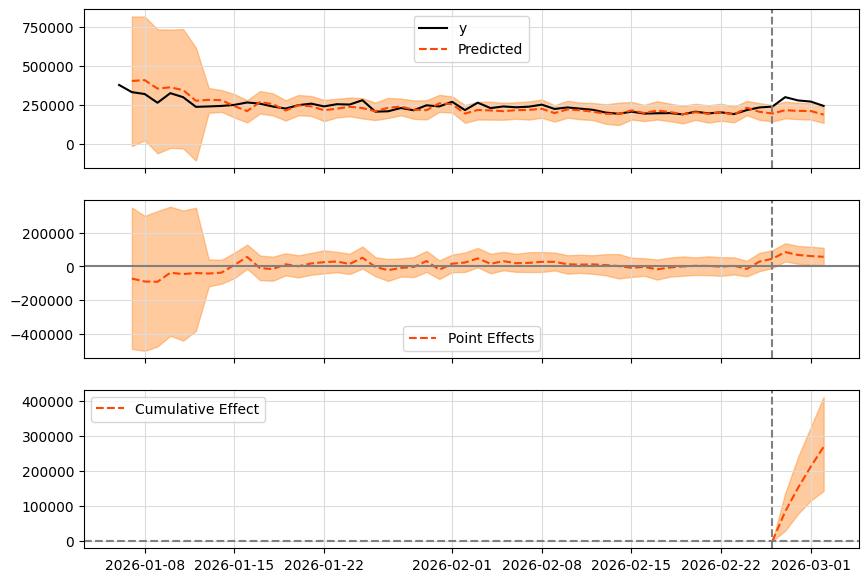

Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    272273.38          1089093.5
Prediction (s.d.)         205047.84 (16107.41)820191.38 (64429.65)
95% CI                    [172161.39, 235301.31][688645.57, 941205.22]

Absolute effect (s.d.)    67225.53 (16107.41)268902.12 (64429.65)
95% CI                    [36972.07, 100111.98][147888.28, 400447.93]

Relative effect (s.d.)    32.79% (7.86%)     32.79% (7.86%)
95% CI                    [18.03%, 48.82%]   [18.03%, 48.82%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


Analysis report {CausalImpact}


During the post-intervention period, the response variable had
an average value of approx. 272273.38. By contrast, in the absence of an
intervention, we would have expected an average response of 205047.84.
The 95% interval of this counterfactual prediction is [172161.3

In [ ]:
revenue_ci.plot()
print(revenue_ci.summary())
print("\n")
print(revenue_ci.summary(output="report"))

In [ ]:
def clean_ci_summary_table(ci, label: str | None = None) -> pd.DataFrame:
    """
    Produce a readable summary table from ci.summary_data with correct labels and formatting.
    Note:
    - For rel_effect rows, average and cumulative are the same ratio by construction.
    - This function keeps the values numeric, then adds a formatted view for display.
    """
    raw = ci.summary_data.copy()
    raw.index.name = "metric"

    rename_map = {
        "actual": "Actual",
        "predicted": "Predicted",
        "predicted_lower": "Predicted lower",
        "predicted_upper": "Predicted upper",
        "abs_effect": "Absolute effect",
        "abs_effect_lower": "Absolute effect lower",
        "abs_effect_upper": "Absolute effect upper",
        "rel_effect": "Relative effect",
        "rel_effect_lower": "Relative effect lower",
        "rel_effect_upper": "Relative effect upper",
    }
    out = raw.rename(index=rename_map).copy()

    display_df = out.copy()

    ratio_rows = [idx for idx in display_df.index if "Relative effect" in idx]
    money_rows = [idx for idx in display_df.index if idx not in ratio_rows]

    for idx in money_rows:
        display_df.loc[idx, "average"] = f"£{out.loc[idx, 'average']:,.2f}"
        display_df.loc[idx, "cumulative"] = f"£{out.loc[idx, 'cumulative']:,.2f}"

    for idx in ratio_rows:
        display_df.loc[idx, "average"] = f"{100 * out.loc[idx, 'average']:.2f}%"
        display_df.loc[idx, "cumulative"] = f"{100 * out.loc[idx, 'cumulative']:.2f}%"

    if label:
        print(label)

    return display_df

revenue_summary_table = clean_ci_summary_table(
    revenue_ci,
    label="Revenue CausalImpact summary"
)
revenue_summary_table

Revenue CausalImpact summary


,average,cumulative
metric,,
Actual,"£272,273.38","£1,089,093.50"
Predicted,"£205,047.84","£820,191.38"
Predicted lower,"£172,161.39","£688,645.57"
Predicted upper,"£235,301.31","£941,205.22"
Absolute effect,"£67,225.53","£268,902.12"
Absolute effect lower,"£36,972.07","£147,888.28"
Absolute effect upper,"£100,111.98","£400,447.93"
Relative effect,32.79%,32.79%
Relative effect lower,18.03%,18.03%


# Validation

Sets seeds so repeated notebook runs are more comparable.

Defines the primary validation model

Forces all placebo and backtest windows to be the same 4-day length as the promo.

Uses a weekly step and max window cap so the notebook does not become painfully slow.

Keeps VI for the validation loop because the package supports both VI and HMC, and VI is the practical choice for repeated fits.

In [ ]:
# ============================================
# Validation config (reused from the experiment tracking section)
# ============================================

np.random.seed(42)
tf.random.set_seed(42)

print("Tracked version:", RUN_CONTEXT["version_id"])
print("Config hash:", RUN_CONTEXT["config_hash_short"])
print("Primary covariates:", PRIMARY_COVARIATES)
print("Validation horizon (days):", VALIDATION_HORIZON_DAYS)
print("Minimum training days:", MIN_TRAIN_DAYS)
print("Rolling step (days):", ROLLING_STEP_DAYS)
print("Max backtest windows:", MAX_BACKTEST_WINDOWS)
print("Validation model args:", VALIDATION_MODEL_ARGS)


Tracked version: uk_revenue_delivery_promo__v003__c8735bf1
Config hash: c8735bf1
Primary covariates: ['sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']
Validation horizon (days): 4
Minimum training days: 56
Rolling step (days): 7
Max backtest windows: 12
Validation model args: {'nseasons': 7, 'standardize_data': True, 'fit_method': 'vi'}


### Helper functions

- Create a reusable CausalImpact runner that lets you override model args for specific checks.

- Extract a clean set of effect metrics from summary_data.

- Extract forecast-quality metrics from the model’s post-period prediction table in ci.inferences.

- Build candidate placebo/backtest windows and evaluates one window at a time

In [ ]:
# ============================================
# Validation helpers
# ============================================

def run_causal_impact_with_args(
    data: pd.DataFrame,
    target_col: str,
    covariates: list[str],
    pre_period: list[str],
    post_period: list[str],
    model_args_override: dict | None = None,
):
    return run_causal_impact(
        data=data,
        target_col=target_col,
        covariates=covariates,
        pre_period=pre_period,
        post_period=post_period,
        model_args_override=model_args_override,
        use_cache=True,
    )

def extract_ci_metrics(ci, label: str) -> dict:
    s = ci.summary_data.copy()

    out = {
        "label": label,
        "actual_avg": float(s.loc["actual", "average"]),
        "actual_cum": float(s.loc["actual", "cumulative"]),
        "pred_avg": float(s.loc["predicted", "average"]),
        "pred_cum": float(s.loc["predicted", "cumulative"]),
        "pred_lower_cum": float(s.loc["predicted_lower", "cumulative"]),
        "pred_upper_cum": float(s.loc["predicted_upper", "cumulative"]),
        "abs_effect_avg": float(s.loc["abs_effect", "average"]),
        "abs_effect_cum": float(s.loc["abs_effect", "cumulative"]),
        "abs_effect_cum_lower": float(s.loc["abs_effect_lower", "cumulative"]),
        "abs_effect_cum_upper": float(s.loc["abs_effect_upper", "cumulative"]),
        "rel_effect": float(s.loc["rel_effect", "average"]),
        "rel_effect_lower": float(s.loc["rel_effect_lower", "average"]),
        "rel_effect_upper": float(s.loc["rel_effect_upper", "average"]),
        "p_value": float(ci.p_value),
    }

    out["effect_direction"] = "positive" if out["abs_effect_cum"] >= 0 else "negative"
    out["prob_same_direction"] = 1 - out["p_value"]
    return out


def compute_post_forecast_metrics(ci, actual_post: pd.Series) -> dict:
    inf = ci.inferences.loc[actual_post.index].copy()

    pred = inf["post_preds_means"].astype(float)
    lower = inf["post_preds_lower"].astype(float)
    upper = inf["post_preds_upper"].astype(float)
    actual = actual_post.astype(float)

    err = actual - pred
    abs_err = np.abs(err)

    denom = actual.abs().replace(0, np.nan)
    ape = abs_err / denom

    return {
        "mae": float(abs_err.mean()),
        "rmse": float(np.sqrt(np.mean(err**2))),
        "mape": float(np.nanmean(ape)),
        "wape": float(abs_err.sum() / actual.abs().sum()) if actual.abs().sum() != 0 else np.nan,
        "mean_bias": float(err.mean()),
        "bias_pct_of_actual": float(err.sum() / actual.sum()) if actual.sum() != 0 else np.nan,
        "coverage_95": float(((actual >= lower) & (actual <= upper)).mean()),
    }


def evenly_cap_dates(dates: list[pd.Timestamp], max_windows: int | None) -> list[pd.Timestamp]:
    if (max_windows is None) or (len(dates) <= max_windows):
        return dates

    idx = np.linspace(0, len(dates) - 1, max_windows, dtype=int)
    return [dates[i] for i in idx]


def build_candidate_post_starts(
    data_index: pd.DatetimeIndex,
    intervention_start: pd.Timestamp,
    horizon_days: int,
    min_train_days: int,
    step_days: int,
    max_windows: int | None = None,
) -> list[pd.Timestamp]:
    earliest_start = data_index.min() + pd.Timedelta(days=min_train_days)
    latest_start = intervention_start - pd.Timedelta(days=horizon_days)

    if latest_start < earliest_start:
        raise ValueError("Not enough pre-period history to build validation windows.")

    starts = list(pd.date_range(earliest_start, latest_start, freq=f"{step_days}D"))

    # Ensure the latest eligible start is included
    if not starts or starts[-1] != latest_start:
        starts.append(latest_start)

    starts = sorted(pd.to_datetime(pd.Index(starts)).unique())
    starts = evenly_cap_dates(starts, max_windows)
    return starts


def evaluate_one_window(
    data: pd.DataFrame,
    target_col: str,
    covariates: list[str],
    post_start: pd.Timestamp,
    horizon_days: int,
    model_args_override: dict | None = None,
) -> dict:
    post_end = post_start + pd.Timedelta(days=horizon_days - 1)
    pre_start = data.index.min()
    pre_end = post_start - pd.Timedelta(days=1)

    pre_period_local = [
        pre_start.strftime("%Y-%m-%d"),
        pre_end.strftime("%Y-%m-%d"),
    ]
    post_period_local = [
        post_start.strftime("%Y-%m-%d"),
        post_end.strftime("%Y-%m-%d"),
    ]

    ci = run_causal_impact_with_args(
        data=data,
        target_col=target_col,
        covariates=covariates,
        pre_period=pre_period_local,
        post_period=post_period_local,
        model_args_override=model_args_override,
    )

    actual_post = data.loc[post_start:post_end, target_col]
    effect_metrics = extract_ci_metrics(ci, label=f"{post_start.date()}_{post_end.date()}")
    forecast_metrics = compute_post_forecast_metrics(ci, actual_post)

    return {
        "post_start": post_start,
        "post_end": post_end,
        "train_days": (pre_end - pre_start).days + 1,
        **effect_metrics,
        **forecast_metrics,
    }

Re-fits the model

Stores that result as the reference effect that all the validation checks will compare against.

In [ ]:
# ============================================
# Primary business model for validation
# Reuse the already-fitted primary model
# ============================================

promo_ci_primary = revenue_ci

promo_primary_metrics = pd.DataFrame(
    [extract_ci_metrics(promo_ci_primary, label="promo_primary_full_covariates")]
)

display(
    promo_primary_metrics.style.format({
        "actual_avg": "£{:,.2f}",
        "actual_cum": "£{:,.2f}",
        "pred_avg": "£{:,.2f}",
        "pred_cum": "£{:,.2f}",
        "pred_lower_cum": "£{:,.2f}",
        "pred_upper_cum": "£{:,.2f}",
        "abs_effect_avg": "£{:,.2f}",
        "abs_effect_cum": "£{:,.2f}",
        "abs_effect_cum_lower": "£{:,.2f}",
        "abs_effect_cum_upper": "£{:,.2f}",
        "rel_effect": "{:.2%}",
        "rel_effect_lower": "{:.2%}",
        "rel_effect_upper": "{:.2%}",
        "p_value": "{:.3f}",
        "prob_same_direction": "{:.2%}",
    })
)

print(promo_ci_primary.summary())

,label,actual_avg,actual_cum,pred_avg,pred_cum,pred_lower_cum,pred_upper_cum,abs_effect_avg,abs_effect_cum,abs_effect_cum_lower,abs_effect_cum_upper,rel_effect,rel_effect_lower,rel_effect_upper,p_value,effect_direction,prob_same_direction
0,promo_primary_full_covariates,"£272,273.38","£1,089,093.50","£205,047.84","£820,191.38","£688,645.57","£941,205.22","£67,225.53","£268,902.12","£147,888.28","£400,447.93",32.79%,18.03%,48.82%,0.000,positive,100.00%


Posterior Inference {Causal Impact}
                          Average            Cumulative
Actual                    272273.38          1089093.5
Prediction (s.d.)         205047.84 (16107.41)820191.38 (64429.65)
95% CI                    [172161.39, 235301.31][688645.57, 941205.22]

Absolute effect (s.d.)    67225.53 (16107.41)268902.12 (64429.65)
95% CI                    [36972.07, 100111.98][147888.28, 400447.93]

Relative effect (s.d.)    32.79% (7.86%)     32.79% (7.86%)
95% CI                    [18.03%, 48.82%]   [18.03%, 48.82%]

Posterior tail-area probability p: 0.0
Posterior prob. of a causal effect: 100.0%

For more details run the command: print(impact.summary('report'))


Gives you the usual CausalImpact plot, but now for the correct headline window.

You should expect to see:

observed vs counterfactual

daily effect

cumulative effect over the 4 promo days

This is still not validation by itself, but it is your anchor view.

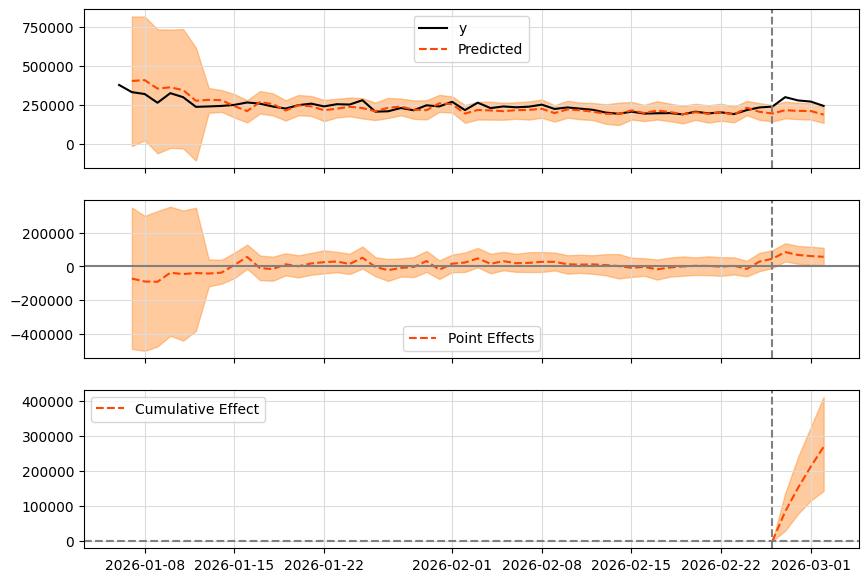

In [ ]:
# ============================================
# Plot the primary promo-only fit
# ============================================

promo_ci_primary.plot()

### Rolling backtests

The rolling backtests validate the Causal Impact model before trusting its results on the real intervention.
The code slides a fake "post-period" window across the pre-intervention history (where no real treatment occurred), fits a Causal Impact model for each window, and records how well the model's counterfactual forecast matches reality.

If the model produces accurate forecasts and near-zero spurious effects across these placebo windows, we can trust it to measure the real intervention reliably.

the rolling backtests answer the question "Does this model produce good predictions and not hallucinate effects where none exist?"

In [ ]:
# ============================================
# Rolling backtests on pre-period windows
# ============================================

backtest_starts = build_candidate_post_starts(
    data_index=data_final.index,
    intervention_start=INTERVENTION_START,
    horizon_days=VALIDATION_HORIZON_DAYS,
    min_train_days=MIN_TRAIN_DAYS,
    step_days=ROLLING_STEP_DAYS,
    max_windows=MAX_BACKTEST_WINDOWS,
)

backtest_rows = []

for post_start in backtest_starts:
    try:
        row = evaluate_one_window(
            data=data_final,
            target_col=TARGET_KPI,
            covariates=PRIMARY_COVARIATES,
            post_start=post_start,
            horizon_days=VALIDATION_HORIZON_DAYS,
            model_args_override=VALIDATION_MODEL_ARGS,
        )
        row["status"] = "ok"
    except Exception as e:
        row = {
            "post_start": post_start,
            "post_end": post_start + pd.Timedelta(days=VALIDATION_HORIZON_DAYS - 1),
            "status": "failed",
            "error": str(e),
        }
    backtest_rows.append(row)

backtest_results = pd.DataFrame(backtest_rows)
backtest_ok = backtest_results.loc[backtest_results["status"] == "ok"].copy()

print(f"Backtests attempted: {len(backtest_results)}")
print(f"Backtests succeeded: {len(backtest_ok)}")

display(
    backtest_ok[
        [
            "post_start",
            "post_end",
            "train_days",
            "wape",
            "mape",
            "rmse",
            "coverage_95",
            "abs_effect_cum",
            "rel_effect",
            "p_value",
        ]
    ].style.format({
        "wape": "{:.2%}",
        "mape": "{:.2%}",
        "rmse": "£{:,.0f}",
        "coverage_95": "{:.2%}",
        "abs_effect_cum": "£{:,.0f}",
        "rel_effect": "{:.2%}",
        "p_value": "{:.3f}",
    })
)

Backtests attempted: 12
Backtests succeeded: 12


,post_start,post_end,train_days,wape,mape,rmse,coverage_95,abs_effect_cum,rel_effect,p_value
0,2024-11-26 00:00:00,2024-11-29 00:00:00,56,29.07%,40.46%,"£518,430",50.00%,"£592,013",11.28%,0.134
1,2024-12-31 00:00:00,2025-01-03 00:00:00,91,42.33%,42.02%,"£200,860",100.00%,"£-702,600",-29.74%,0.049
2,2025-02-11 00:00:00,2025-02-14 00:00:00,133,25.57%,25.37%,"£72,430",100.00%,"£283,118",34.35%,0.230
3,2025-03-25 00:00:00,2025-03-28 00:00:00,175,34.94%,35.00%,"£125,351",100.00%,"£498,934",53.71%,0.062
4,2025-05-06 00:00:00,2025-05-09 00:00:00,217,13.06%,12.88%,"£47,989",100.00%,"£170,896",15.02%,0.249
5,2025-06-17 00:00:00,2025-06-20 00:00:00,259,10.45%,9.71%,"£51,825",100.00%,"£-164,230",-9.46%,0.281
6,2025-07-29 00:00:00,2025-08-01 00:00:00,301,6.50%,6.35%,"£38,605",100.00%,"£135,678",6.95%,0.296
7,2025-09-09 00:00:00,2025-09-12 00:00:00,343,6.80%,7.15%,"£32,639",100.00%,"£-55,005",-4.02%,0.408
8,2025-10-21 00:00:00,2025-10-24 00:00:00,385,2.57%,2.58%,"£11,157",100.00%,£86,0.01%,0.470
9,2025-12-02 00:00:00,2025-12-05 00:00:00,427,24.38%,24.69%,"£132,980",100.00%,"£-506,858",-19.60%,0.051


**wape -- Weighted Absolute Percentage Error**

- Formula: sum(|actual - predicted|) / sum(|actual|)
- What it tells you: The total forecasting error as a share of total actual values. Unlike MAPE, it weights each day's error by that day's magnitude, so high-revenue days matter more and days with near-zero actuals don't blow up the metric.
- Good values: Lower is better. The notebook's validation threshold is median WAPE <= 15%. Single-digit WAPE is strong.

**mape -- Mean Absolute Percentage Error**

- Formula: mean(|actual - predicted| / |actual|) per day
- What it tells you: The average per-day percentage error. Each day is weighted equally regardless of revenue size.
- Good values: Lower is better. < 10% is generally good. Can be inflated by days with small actuals.

**rmse -- Root Mean Squared Error**

- Formula: sqrt(mean((actual - predicted)^2))
- What it tells you: The typical magnitude of error in absolute terms (GBP), with extra penalty for large misses on individual days.
- Good values: Lower is better. Interpret relative to the scale of the target KPI -- e.g. if daily revenue is ~£50k, an RMSE of £1,250 is quite good.

**coverage_95 -- 95% Credible Interval Coverage**

- Formula: fraction of days where actual falls within the model's 95% prediction interval
- What it tells you: Whether the model's uncertainty bands are well-calibrated. If the model says "I'm 95% confident the value is between X and Y", then roughly 95% of actual observations should indeed land in that range.
- Good values: Should be close to or above 95%. The notebook's threshold is mean coverage >= 80%. Well below 95% means the model is overconfident; well above means it's very conservative (wide intervals).

**bias_pct_of_actual -- Bias Percentage of Actual**

- Formula: sum(actual - predicted) / sum(actual)
- What it tells you: The directional systematic error of the model's forecast, expressed as a share of total actuals. Unlike WAPE and MAPE (which use absolute errors and are always positive), bias preserves the sign:
Positive bias means the model consistently under-predicts (actuals are higher than forecasts).
Negative bias means the model consistently over-predicts (actuals are lower than forecasts).
- Good values: Should be close to 0%. A well-calibrated model should over-predict on some days and under-predict on others, with errors roughly cancelling out.

**abs_effect_cum -- Cumulative Absolute Effect**

- Formula: Cumulative sum of (actual - counterfactual prediction) across the placebo window, from CausalImpact.summary_data
- What it tells you: The total "effect" the model attributes to the fake intervention in that window. Since no real intervention happened, **this should be close to zero.**
- How to use: Compare the distribution of placebo abs_effect_cum values to the real intervention's effect. If the real effect is much larger than anything seen in the placebo windows, it's credible. The notebook computes a placebo rank for this purpose.

**rel_effect -- Relative Effect**

- Formula: abs_effect / predicted_counterfactual (average), from CausalImpact.summary_data
- What it tells you: The spurious effect as a percentage of what the model predicted would have happened. Since there is no true effect, this should hover near 0% across windows.
- How to use: If placebo windows regularly show relative effects of e.g. +/-5%, then a real intervention effect of +3% would not be distinguishable from noise.

**p_value -- Bayesian One-Sided Tail-Area Probability**

- Formula: From CausalImpact.p_value -- the posterior probability of observing an effect at least as extreme as the one measured, under the null of no effect.
- What it tells you: Whether the detected "effect" in this placebo window is statistically significant. Since no real effect exists, p-values should generally be high (> 0.05) -- i.e. the model correctly fails to reject the null.
- How to use: If many placebo windows show p < 0.05, the model has a high false-positive rate and should not be trusted. Conversely, when you run the model on the real intervention, a low p-value (< 0.05) is meaningful only if the placebo backtests show the model isn't prone to false positives.

In [ ]:
# ============================================
# Backtest summary table
# ============================================

backtest_summary = pd.DataFrame({
    "metric": ["WAPE", "MAPE", "RMSE", "95% interval coverage", "Bias % of actual"],
    "median": [
        backtest_ok["wape"].median(),
        backtest_ok["mape"].median(),
        backtest_ok["rmse"].median(),
        backtest_ok["coverage_95"].median(),
        backtest_ok["bias_pct_of_actual"].median(),
    ],
    "mean": [
        backtest_ok["wape"].mean(),
        backtest_ok["mape"].mean(),
        backtest_ok["rmse"].mean(),
        backtest_ok["coverage_95"].mean(),
        backtest_ok["bias_pct_of_actual"].mean(),
    ],
    "p90": [
        backtest_ok["wape"].quantile(0.90),
        backtest_ok["mape"].quantile(0.90),
        backtest_ok["rmse"].quantile(0.90),
        backtest_ok["coverage_95"].quantile(0.90),
        backtest_ok["bias_pct_of_actual"].quantile(0.90),
    ],
})

display(
    backtest_summary.style.format({
        "median": lambda x: f"{x:.2%}" if abs(x) < 10 else f"£{x:,.0f}",
        "mean": lambda x: f"{x:.2%}" if abs(x) < 10 else f"£{x:,.0f}",
        "p90": lambda x: f"{x:.2%}" if abs(x) < 10 else f"£{x:,.0f}",
    })
)

,metric,median,mean,p90
0,WAPE,13.25%,17.42%,34.36%
1,MAPE,13.20%,19.95%,40.46%
2,RMSE,"£51,825","£115,356","£200,860"
3,95% interval coverage,100.00%,87.50%,100.00%
4,Bias % of actual,0.00%,0.60%,24.32%


Shows whether forecast quality is stable or whether the model struggles in particular retail periods.

If you see one or two ugly spikes, inspect those dates. They often line up with unmodelled promos or strange calendar effects.

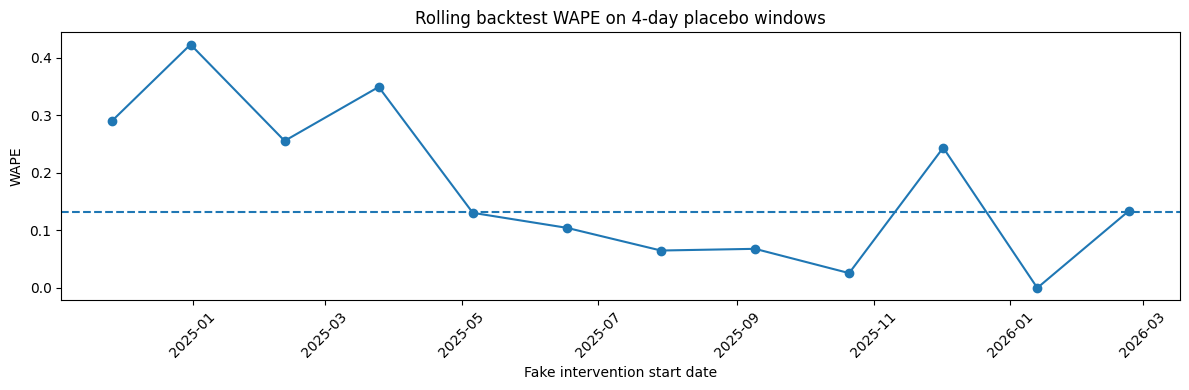

In [ ]:
# ============================================
# Plot backtest WAPE through time
# ============================================

plt.figure(figsize=(12, 4))
plt.plot(backtest_ok["post_start"], backtest_ok["wape"], marker="o")
plt.axhline(backtest_ok["wape"].median(), linestyle="--")
plt.title("Rolling backtest WAPE on 4-day placebo windows")
plt.xlabel("Fake intervention start date")
plt.ylabel("WAPE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Placebo effect test

The placebo effect test checks whether the real intervention's measured effect is genuinely unusual, or whether the model routinely produces "effects" of similar size even when nothing happened.

It takes the cumulative causal effect estimated on the real promotion window (real_effect_cum) and compares it against the distribution of spurious effects from all the rolling backtest windows -- where no actual intervention took place. The histogram shows where the real effect sits relative to these placebo effects, and the percentile rank quantifies how extreme it is.

it answers: "Could this effect have arisen by chance from normal model noise, or is it a genuine outlier?"

**Placebo rank** the fraction of placebo effects that are less extreme than the real effect:

- 95%+	Very strong evidence. The real effect is larger than 95%+ of all placebo effects -- it would be extremely unlikely to see this by chance.
- 90-95%	Good evidence. The notebook's validation threshold is >= 90%.
- 70-90%	Weak evidence. The real effect is bigger than most placebo effects, but not dramatically so. The model sometimes produces spurious effects of comparable size.
- < 70%	Not credible. Many placebo windows produced "effects" just as large or larger. The measured intervention effect could easily be noise.


**The histogram** visualises the distribution of abs_effect_cum values from all placebo backtest windows. The dashed vertical line marks the real promotion's effect. You want to see:

The dashed line sitting far to the right (for a positive effect) or far to the left (for a negative effect) of the bulk of the histogram -- this means the real effect is an outlier compared to what the model produces when no intervention exists.
If the dashed line sits inside the main body of the histogram, the real effect is indistinguishable from noise.

**abs_effect_cum -- Cumulative Absolute Effect**

- Formula: Cumulative sum of (actual - counterfactual prediction) across the placebo window, from CausalImpact.summary_data
- What it tells you: The total "effect" the model attributes to the fake intervention in that window. Since no real intervention happened, **this should be close to zero.**
- How to use: Compare the distribution of placebo abs_effect_cum values to the real intervention's effect. If the real effect is much larger than anything seen in the placebo windows, it's credible. The notebook computes a placebo rank for this purpose.

Real promo cumulative effect: £268,902
Percentile rank vs placebo windows: 66.7%


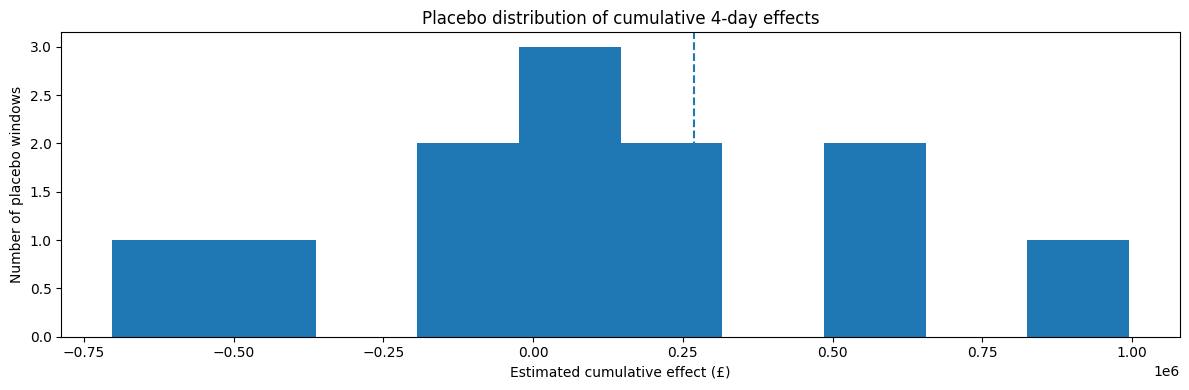

In [ ]:
# ============================================
# Placebo effect distribution
# ============================================

real_effect_cum = float(promo_primary_metrics.loc[0, "abs_effect_cum"])

placebo_effects = backtest_ok["abs_effect_cum"].dropna().copy()

if real_effect_cum >= 0:
    placebo_rank = float((placebo_effects < real_effect_cum).mean())
else:
    placebo_rank = float((placebo_effects > real_effect_cum).mean())

print(f"Real promo cumulative effect: £{real_effect_cum:,.0f}")
print(f"Percentile rank vs placebo windows: {placebo_rank:.1%}")

plt.figure(figsize=(12, 4))
plt.hist(placebo_effects, bins=min(10, len(placebo_effects)))
plt.axvline(real_effect_cum, linestyle="--")
plt.title("Placebo distribution of cumulative 4-day effects")
plt.xlabel("Estimated cumulative effect (£)")
plt.ylabel("Number of placebo windows")
plt.tight_layout()
plt.show()

### Sensitivity test

The sensitivity analysis re-runs the Causal Impact model on the real intervention period using different sets of covariates, to check whether the estimated causal effect is robust to modelling choices.
The code first includes the primary (full) model's results, then iterates over three alternative covariate specifications -- sessions_only, sessions_plus_calendar, and sessions_plus_trading_context -- each a subset or variation of the primary covariates.
If every specification agrees on the direction and approximate magnitude of the effect, the finding is credible. If the effect changes sign or magnitude drastically depending on which covariates are included, it may be an artefact of a particular model configuration.

In [ ]:
# ============================================
# Sensitivity analysis across covariate bundles
# ============================================

assert_run_context_is_current()

sensitivity_rows = []

# Reuse the already-fitted primary model instead of fitting the same thing again
primary_row = extract_ci_metrics(promo_ci_primary, label="full_model")
primary_row["n_covariates"] = len(PRIMARY_COVARIATES)
primary_row["covariates"] = ", ".join(PRIMARY_COVARIATES)
primary_row["status"] = "ok"
primary_row["reused_primary_fit"] = True
sensitivity_rows.append(primary_row)

for spec_name, spec_covars in SENSITIVITY_SPECS.items():
    try:
        ci = run_causal_impact_with_args(
            data=data_final,
            target_col=TARGET_KPI,
            covariates=spec_covars,
            pre_period=pre_period,
            post_period=promo_window,
            model_args_override=VALIDATION_MODEL_ARGS,
        )
        row = extract_ci_metrics(ci, label=spec_name)
        row["n_covariates"] = len(spec_covars)
        row["covariates"] = ", ".join(spec_covars)
        row["status"] = "ok"
        row["reused_primary_fit"] = False
    except Exception as e:
        row = {
            "label": spec_name,
            "status": "failed",
            "error": str(e),
            "reused_primary_fit": False,
        }
    sensitivity_rows.append(row)

sensitivity_results = pd.DataFrame(sensitivity_rows)

display(
    sensitivity_results[
        [
            "label",
            "status",
            "reused_primary_fit",
            "abs_effect_cum",
            "abs_effect_cum_lower",
            "abs_effect_cum_upper",
            "rel_effect",
            "rel_effect_lower",
            "rel_effect_upper",
            "p_value",
            "n_covariates",
            "covariates",
        ]
    ].style.format({
        "abs_effect_cum": "£{:,.0f}",
        "abs_effect_cum_lower": "£{:,.0f}",
        "abs_effect_cum_upper": "£{:,.0f}",
        "rel_effect": "{:.2%}",
        "rel_effect_lower": "{:.2%}",
        "rel_effect_upper": "{:.2%}",
        "p_value": "{:.3f}",
    })
)


,label,status,reused_primary_fit,abs_effect_cum,abs_effect_cum_lower,abs_effect_cum_upper,rel_effect,rel_effect_lower,rel_effect_upper,p_value,n_covariates,covariates
0,full_model,ok,True,"£268,902","£147,888","£400,448",32.79%,18.03%,48.82%,0.000,7,"sessions, winter_sale_flag, student_20_flag, loyalty_discount_restriction_post_flag, is_weekend, payday_window_flag, kcp_period_flag"
1,sessions_only,ok,False,"£249,933","£156,837","£353,792",29.78%,18.69%,42.16%,0.000,1,sessions
2,sessions_plus_calendar,ok,False,"£246,135","£139,415","£359,608",29.20%,16.54%,42.66%,0.000,3,"sessions, is_weekend, payday_window_flag"
3,sessions_plus_trading_context,ok,False,"£231,002","£119,723","£327,494",26.92%,13.95%,38.17%,0.000,5,"sessions, winter_sale_flag, student_20_flag, loyalty_discount_restriction_post_flag, kcp_period_flag"


- abs_effect_cum: Cumulative causal effect in GBP for this specification	Should be consistent across rows. If the full model says +£10,000 and another spec says -£2,000, the result is fragile.
- abs_effect_cum_lower: Lower bound of the 95% credible interval for the cumulative effect	Gives the pessimistic end of the effect estimate
- abs_effect_cum_upper	Upper bound of the 95% credible interval for the cumulative effect	Gives the optimistic end of the effect estimate
- rel_effect	Relative effect (effect as % of counterfactual)	Should point in the same direction across specs. E.g. all showing +5% to +8% is reassuring.
- rel_effect_lower	Lower bound of the 95% credible interval for relative effect	If this is positive across all specs, even the conservative estimate says the intervention helped
- rel_effect_upper	Upper bound of the 95% credible interval for relative effect
- p_value	Bayesian tail-area probability

HOW TO READ:
- All rows show same sign for abs_effect_cum and rel_effect	Effect direction is robust
- All rows show p_value < 0.05	Statistical significance is robust
- abs_effect_cum values are within ~20-30% of each other	Effect magnitude is stable
- Credible intervals overlap across rows	Specifications agree within uncertainty
- One row flips sign or has p >> 0.05	That specification disagrees -- investigate why (which covariates were added/removed and what they control for)

### HMC check

What Is HMC?
HMC stands for Hamiltonian Monte Carlo (also called Hybrid Monte Carlo). It is an alternative method for fitting the Bayesian structural time series model that underpins CausalImpact.

By default, the causalimpact Python library fits the model using variational inference (a fast approximation). HMC is a full Markov Chain Monte Carlo (MCMC) sampling method -- it draws samples from the true posterior distribution rather than approximating it. It is significantly slower but theoretically more accurate, especially for the uncertainty estimates (credible intervals and p-values).

Short Description of the Code
This optional cell re-fits the exact same primary model (same covariates, same time periods) but swaps the fitting method from the default variational inference to HMC. It then extracts and displays the same causal effect metrics. The purpose is a sanity check: if the fast default method produced reliable estimates, the HMC results should closely match. If they diverge significantly, the default method's approximation may not be trustworthy for this particular dataset.

The check is gated behind RUN_HMC_CHECK = False because HMC is much slower to run and is not needed every time -- only when you want to verify the robustness of the inference method itself.

- abs_effect_cum	Close to the primary model's value	Differs by more than ~20-30%
- rel_effect	Close to the primary model's value	Different direction or very different magnitude
- p_value	Similar order of magnitude	One says p = 0.01, the other says p = 0.30
- abs_effect_cum_lower / upper	Interval width roughly similar	HMC intervals are dramatically wider or narrower
- prob_same_direction	Both high (e.g. both > 95%)	One is confident, the other is not

Results agree closely -- The default variational fit is a good approximation for this data. You can trust the faster method and don't need to run HMC routinely. This is the most common outcome.

Effect direction and significance agree, but intervals differ -- The point estimates match but HMC gives wider or narrower credible intervals. This means the default method is slightly mis-calibrating uncertainty. The effect is likely real, but you may want to report the HMC intervals as more reliable.

Results disagree substantially -- The effect size, direction, or significance changes between methods. This means the variational approximation is not reliable for this dataset. You should use the HMC results as the ground truth, or investigate why the model is difficult to fit (e.g. too few data points, multicollinearity in covariates, non-stationary patterns).

In [ ]:
# ============================================
# Optional: HMC check on the primary spec
# ============================================

RUN_HMC_CHECK = True

if RUN_HMC_CHECK:
    hmc_ci = run_causal_impact_with_args(
        data=data_final,
        target_col=TARGET_KPI,
        covariates=PRIMARY_COVARIATES,
        pre_period=pre_period,
        post_period=promo_window,
        model_args_override={
            **VALIDATION_MODEL_ARGS,
            "fit_method": "hmc",
        },
    )

    hmc_metrics = pd.DataFrame([extract_ci_metrics(hmc_ci, label="primary_no_sessions_hmc")])

    display(
        hmc_metrics.style.format({
            "actual_avg": "£{:,.2f}",
            "actual_cum": "£{:,.2f}",
            "pred_avg": "£{:,.2f}",
            "pred_cum": "£{:,.2f}",
            "pred_lower_cum": "£{:,.2f}",
            "pred_upper_cum": "£{:,.2f}",
            "abs_effect_avg": "£{:,.2f}",
            "abs_effect_cum": "£{:,.2f}",
            "abs_effect_cum_lower": "£{:,.2f}",
            "abs_effect_cum_upper": "£{:,.2f}",
            "rel_effect": "{:.2%}",
            "rel_effect_lower": "{:.2%}",
            "rel_effect_upper": "{:.2%}",
            "p_value": "{:.3f}",
            "prob_same_direction": "{:.2%}",
        })
    )

,label,actual_avg,actual_cum,pred_avg,pred_cum,pred_lower_cum,pred_upper_cum,abs_effect_avg,abs_effect_cum,abs_effect_cum_lower,abs_effect_cum_upper,rel_effect,rel_effect_lower,rel_effect_upper,p_value,effect_direction,prob_same_direction
0,primary_no_sessions_hmc,"£272,273.38","£1,089,093.50","£220,164.39","£880,657.56","£789,813.03","£972,830.32","£52,108.98","£208,435.94","£116,263.18","£299,280.47",23.67%,13.20%,33.98%,0.000,positive,100.00%


## Tests overview

In [ ]:
# ============================================
# Final "good enough?" scorecard
# ============================================

n_ok_specs = sensitivity_results.loc[sensitivity_results["status"] == "ok", "label"].nunique()
required_positive_share = (n_ok_specs - 1) / n_ok_specs if n_ok_specs > 0 else np.nan

VALIDATION_THRESHOLDS = {
    "max_median_wape": 0.15,
    "min_mean_coverage": 0.80,
    "min_placebo_rank": 0.90,
    "min_positive_spec_share": required_positive_share,
    "max_primary_p_value": 0.10,
}

positive_spec_share = (
    sensitivity_results.loc[sensitivity_results["status"] == "ok", "abs_effect_cum"] > 0
).mean()

scorecard = pd.DataFrame([
    {
        "check": "Median 4-day backtest WAPE <= 15%",
        "value": backtest_ok["wape"].median(),
        "threshold": VALIDATION_THRESHOLDS["max_median_wape"],
        "pass": backtest_ok["wape"].median() <= VALIDATION_THRESHOLDS["max_median_wape"],
    },
    {
        "check": "Mean 95% interval coverage >= 80%",
        "value": backtest_ok["coverage_95"].mean(),
        "threshold": VALIDATION_THRESHOLDS["min_mean_coverage"],
        "pass": backtest_ok["coverage_95"].mean() >= VALIDATION_THRESHOLDS["min_mean_coverage"],
    },
    {
        "check": "Real promo effect ranks >= 90th percentile vs placebo",
        "value": placebo_rank,
        "threshold": VALIDATION_THRESHOLDS["min_placebo_rank"],
        "pass": placebo_rank >= VALIDATION_THRESHOLDS["min_placebo_rank"],
    },
    {
        "check": f"At least {max(n_ok_specs - 1, 0)}/{n_ok_specs} specs are positive",
        "value": positive_spec_share,
        "threshold": VALIDATION_THRESHOLDS["min_positive_spec_share"],
        "pass": positive_spec_share >= VALIDATION_THRESHOLDS["min_positive_spec_share"],
    },
    {
        "check": "Primary promo model p-value <= 0.10",
        "value": float(promo_primary_metrics.loc[0, "p_value"]),
        "threshold": VALIDATION_THRESHOLDS["max_primary_p_value"],
        "pass": float(promo_primary_metrics.loc[0, "p_value"]) <= VALIDATION_THRESHOLDS["max_primary_p_value"],
    },
])

display(
    scorecard.style.format({
        "value": "{:.2%}",
        "threshold": "{:.2%}",
    })
)

,check,value,threshold,pass
0,Median 4-day backtest WAPE <= 15%,13.25%,15.00%,True
1,Mean 95% interval coverage >= 80%,87.50%,80.00%,True
2,Real promo effect ranks >= 90th percentile vs placebo,66.67%,90.00%,False
3,At least 3/4 specs are positive,100.00%,75.00%,True
4,Primary promo model p-value <= 0.10,0.00%,10.00%,True


# Save experiment in GDrive
This section saves the tracked run to the shared Google Drive folder and refreshes the registry / leaderboard.

**You can run this cell at two points:**

1. **After Results and Interpretation only** — saves the config, primary metrics (p-value, effect size), and the CausalImpact plot. The record is tagged `validation_status: "results_only"`.
2. **After running the Validation section** — re-run this cell and it will **update the same registry row** with full test results (backtests, placebo rank, sensitivity, scorecard) and set `validation_status: "validated"`.

For each run it stores:
- the exact config
- version metadata
- primary metrics (always available from the fitted model)
- validation outputs (backtests, sensitivity, scorecard, placebo — only when validation has been run)
- the main charts

Because the config hash is checked again here, the save step will also stop if the notebook setup changed after the version metadata was created.


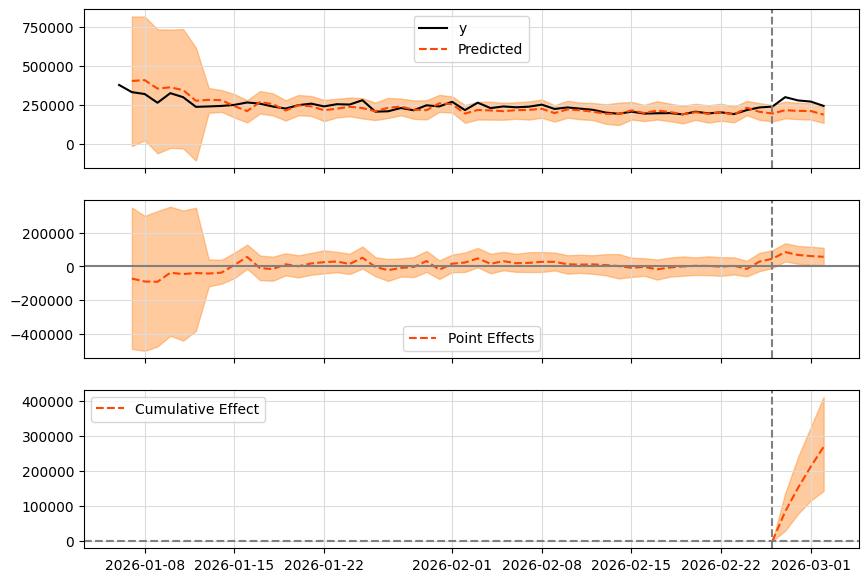

Saved run to Google Drive. [validation_status: validated]
Version folder: https://drive.google.com/drive/folders/1EwT5WBF7f02OBJzrIO4jlthXfiH1ZnHh
Registry file: uk_revenue_delivery_promo__experiment_registry.csv


,created_at,experiment_name,pipeline_version,version_num,version_id,run_attempt,run_id,is_new_version,config_hash,config_hash_short,...,validation_passed,version_folder_name,median_backtest_wape,mean_backtest_wape,mean_coverage_95,placebo_rank,positive_spec_share,n_uploaded_files,drive_version_folder_id,drive_version_folder_url
0,2026-03-17T16:22:08.872678+00:00,uk_revenue_delivery_promo,2026-03-17_v1,3,uk_revenue_delivery_promo__v003__c8735bf1,1,uk_revenue_delivery_promo__v003__c8735bf1__run...,True,c8735bf11df2856aeb372c5ba5b3a17b9f54728239aadb...,c8735bf1,...,False,uk_revenue_delivery_promo__v003__c8735bf1,0.132467,0.174243,0.875,0.666667,1.0,11,1EwT5WBF7f02OBJzrIO4jlthXfiH1ZnHh,https://drive.google.com/drive/folders/1EwT5WB...


Latest run per version:


,version_id,run_attempt,user_email,covariates,median_backtest_wape,mean_coverage_95,placebo_rank,primary_p_value,primary_rel_effect,validation_status,validation_passed,created_at
0,uk_revenue_delivery_promo__v002__8141ac12,1,elena.nesi@monks.com,sessions | winter_sale_flag | student_20_flag | loyalty_discount_restriction_post_flag | is_weekend | payday_window_flag | kcp_period_flag | yearend_period_flag,11.61%,87.50%,66.67%,0.311,17.15%,validated,False,2026-03-17T14:59:13.289399+00:00
1,uk_revenue_delivery_promo__v003__c8735bf1,1,elena.nesi@monks.com,sessions | winter_sale_flag | student_20_flag | loyalty_discount_restriction_post_flag | is_weekend | payday_window_flag | kcp_period_flag,13.25%,87.50%,66.67%,0.000,32.79%,validated,False,2026-03-17T16:22:08.872678+00:00
2,uk_revenue_delivery_promo__v001__2d80a644,1,elena.nesi@monks.com,paid_sessions | winter_sale_flag | student_20_flag | loyalty_discount_restriction_post_flag | is_weekend | payday_window_flag | kcp_period_flag,15.30%,87.50%,66.67%,0.311,17.15%,validated,False,2026-03-17T12:43:47.254518+00:00


In [ ]:
# ============================================
# Persist artifacts to Google Drive and show the registry / leaderboard
# ============================================

assert_run_context_is_current()

# ---------------------------------------------------------------------------
# Detect whether full validation has been run in this session.
# When saving without validation the record is marked "results_only";
# re-running this cell after validation updates the same registry row.
# ---------------------------------------------------------------------------
_has_validation = False
try:
    _has_validation = (
        isinstance(backtest_ok, pd.DataFrame) and not backtest_ok.empty
        and isinstance(sensitivity_results, pd.DataFrame) and not sensitivity_results.empty
        and isinstance(scorecard, pd.DataFrame) and not scorecard.empty
        and isinstance(placebo_rank, (int, float))
    )
except NameError:
    pass

_has_promo_metrics = False
try:
    _has_promo_metrics = isinstance(promo_primary_metrics, pd.DataFrame) and not promo_primary_metrics.empty
except NameError:
    pass

if not _has_promo_metrics:
    _s = revenue_ci.summary_data
    promo_primary_metrics = pd.DataFrame([{
        "label": "promo_primary_full_covariates",
        "actual_avg": float(_s.loc["actual", "average"]),
        "actual_cum": float(_s.loc["actual", "cumulative"]),
        "pred_avg": float(_s.loc["predicted", "average"]),
        "pred_cum": float(_s.loc["predicted", "cumulative"]),
        "pred_lower_cum": float(_s.loc["predicted_lower", "cumulative"]),
        "pred_upper_cum": float(_s.loc["predicted_upper", "cumulative"]),
        "abs_effect_avg": float(_s.loc["abs_effect", "average"]),
        "abs_effect_cum": float(_s.loc["abs_effect", "cumulative"]),
        "abs_effect_cum_lower": float(_s.loc["abs_effect_lower", "cumulative"]),
        "abs_effect_cum_upper": float(_s.loc["abs_effect_upper", "cumulative"]),
        "rel_effect": float(_s.loc["rel_effect", "average"]),
        "rel_effect_lower": float(_s.loc["rel_effect_lower", "average"]),
        "rel_effect_upper": float(_s.loc["rel_effect_upper", "average"]),
        "p_value": float(revenue_ci.p_value),
    }])


def save_json(payload: dict | list, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as fh:
        json.dump(_json_ready(payload), fh, indent=2, ensure_ascii=False)
    return path


def save_dataframe(df: pd.DataFrame, path: Path) -> Path:
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    return path


def render_ci_plot(path: Path) -> Path:
    plt.close("all")
    revenue_ci.plot()
    plt.gcf().savefig(path, dpi=150, bbox_inches="tight")
    plt.close("all")
    return path


def render_backtest_wape_plot(path: Path) -> Path:
    plt.close("all")
    plt.figure(figsize=(12, 4))
    plt.plot(backtest_ok["post_start"], backtest_ok["wape"], marker="o")
    plt.axhline(backtest_ok["wape"].median(), linestyle="--")
    plt.title("Rolling backtest WAPE on 4-day placebo windows")
    plt.xlabel("Fake intervention start date")
    plt.ylabel("WAPE")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close("all")
    return path


def render_placebo_plot(path: Path) -> Path:
    plt.close("all")
    placebo_effects = backtest_ok["abs_effect_cum"].dropna().copy()
    plt.figure(figsize=(12, 4))
    plt.hist(placebo_effects, bins=min(10, len(placebo_effects)))
    plt.axvline(float(promo_primary_metrics.loc[0, "abs_effect_cum"]), linestyle="--")
    plt.title("Placebo distribution of cumulative 4-day effects")
    plt.xlabel("Estimated cumulative effect (£)")
    plt.ylabel("Number of placebo windows")
    plt.tight_layout()
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close("all")
    return path


def build_run_record() -> dict:
    if _has_validation:
        validation_status = "validated"
        validation_passed = bool(scorecard["pass"].fillna(False).all())
    else:
        validation_status = "results_only"
        validation_passed = None

    record = {
        "created_at": RUN_CONTEXT["created_at"],
        "experiment_name": RUN_CONTEXT["experiment_name"],
        "pipeline_version": RUN_CONTEXT["pipeline_version"],
        "version_num": RUN_CONTEXT["version_num"],
        "version_id": RUN_CONTEXT["version_id"],
        "run_attempt": RUN_CONTEXT["run_attempt"],
        "run_id": RUN_CONTEXT["run_id"],
        "is_new_version": RUN_CONTEXT["is_new_version"],
        "config_hash": RUN_CONTEXT["config_hash"],
        "config_hash_short": RUN_CONTEXT["config_hash_short"],
        "user_email": RUN_CONTEXT["user_email"],
        "user_name": RUN_CONTEXT["user_name"],
        "optional_note": RUN_CONTEXT["optional_note"],
        "target_kpi": TARGET_KPI,
        "pre_period_start": pre_period[0],
        "pre_period_end": pre_period[1],
        "promo_start": promo_window[0],
        "promo_end": promo_window[1],
        "covariates": " | ".join(PRIMARY_COVARIATES),
        "n_covariates": len(PRIMARY_COVARIATES),
        "fit_method": PRIMARY_MODEL_ARGS.get("fit_method"),
        "primary_p_value": float(promo_primary_metrics.loc[0, "p_value"]),
        "primary_rel_effect": float(promo_primary_metrics.loc[0, "rel_effect"]),
        "primary_abs_effect_cum": float(promo_primary_metrics.loc[0, "abs_effect_cum"]),
        "validation_status": validation_status,
        "validation_passed": validation_passed,
        "version_folder_name": RUN_CONTEXT["version_folder_name"],
    }

    if _has_validation:
        record.update({
            "median_backtest_wape": float(backtest_ok["wape"].median()),
            "mean_backtest_wape": float(backtest_ok["wape"].mean()),
            "mean_coverage_95": float(backtest_ok["coverage_95"].mean()),
            "placebo_rank": float(placebo_rank),
            "positive_spec_share": float(
                (sensitivity_results.loc[sensitivity_results["status"] == "ok", "abs_effect_cum"] > 0).mean()
            ),
        })
    else:
        record.update({
            "median_backtest_wape": None,
            "mean_backtest_wape": None,
            "mean_coverage_95": None,
            "placebo_rank": None,
            "positive_spec_share": None,
        })

    return record


run_dir = Path(RUN_CONTEXT["local_run_dir"])
run_dir.mkdir(parents=True, exist_ok=True)

# Always-available artifacts
config_path = save_json(EXPERIMENT_CONFIG, run_dir / "config.json")
context_path = save_json(RUN_CONTEXT, run_dir / "version_metadata.json")
primary_metrics_path = save_dataframe(promo_primary_metrics, run_dir / "promo_primary_metrics.csv")
summary_data_path = save_dataframe(revenue_ci.summary_data.reset_index(), run_dir / "causal_impact_summary_data.csv")
ci_plot_path = render_ci_plot(run_dir / "causal_impact_plot.png")

# Validation-only artifacts
if _has_validation:
    backtests_path = save_dataframe(backtest_results, run_dir / "backtest_results.csv")
    sensitivity_path = save_dataframe(sensitivity_results, run_dir / "sensitivity_results.csv")
    scorecard_path = save_dataframe(scorecard, run_dir / "validation_scorecard.csv")
    wape_plot_path = render_backtest_wape_plot(run_dir / "backtest_wape_plot.png")
    placebo_plot_path = render_placebo_plot(run_dir / "placebo_effect_plot.png")

run_record = build_run_record()
run_record_path = save_json(run_record, run_dir / "run_record.json")

# Upload into a version-specific Drive folder.
# update_if_exists=True so re-running after validation overwrites the same files.
version_folder_id = ensure_drive_folder(DRIVE_FOLDER_ID, RUN_CONTEXT["version_folder_name"])

artifact_manifest = [
    (config_path, "application/json"),
    (context_path, "application/json"),
    (primary_metrics_path, "text/csv"),
    (summary_data_path, "text/csv"),
    (ci_plot_path, "image/png"),
    (run_record_path, "application/json"),
]

if _has_validation:
    artifact_manifest.extend([
        (backtests_path, "text/csv"),
        (sensitivity_path, "text/csv"),
        (scorecard_path, "text/csv"),
        (wape_plot_path, "image/png"),
        (placebo_plot_path, "image/png"),
    ])

uploaded_files = []
for local_path, mime_type in artifact_manifest:
    drive_name = f"{RUN_CONTEXT['run_id']}__{local_path.name}"
    uploaded = upload_or_update_file(
        local_path=local_path,
        parent_folder_id=version_folder_id,
        name=drive_name,
        mime_type=mime_type,
        update_if_exists=True,
    )
    uploaded_files.append({
        "local_name": local_path.name,
        "drive_file_id": uploaded.get("id"),
        "drive_name": uploaded.get("name"),
        "webViewLink": uploaded.get("webViewLink"),
    })

run_record["n_uploaded_files"] = len(uploaded_files)
run_record["drive_version_folder_id"] = version_folder_id
run_record["drive_version_folder_url"] = f"https://drive.google.com/drive/folders/{version_folder_id}"

# Update registry: replace any existing row with the same run_id, then append.
registry_local_path = LOCAL_RUNS_ROOT / RUN_CONTEXT["registry_filename"]
REGISTRY_DF = load_registry_from_drive()

if "run_id" in REGISTRY_DF.columns:
    _existing_mask = REGISTRY_DF["run_id"] == RUN_CONTEXT["run_id"]
    if _existing_mask.any():
        REGISTRY_DF = REGISTRY_DF.loc[~_existing_mask].copy()
        print(f"Updating existing registry entry for run_id: {RUN_CONTEXT['run_id']}")

if "validation_status" not in REGISTRY_DF.columns and not REGISTRY_DF.empty:
    REGISTRY_DF["validation_status"] = "validated"

REGISTRY_DF = pd.concat([REGISTRY_DF, pd.DataFrame([run_record])], ignore_index=True)
REGISTRY_DF = REGISTRY_DF.sort_values(["version_num", "run_attempt", "created_at"]).reset_index(drop=True)
REGISTRY_DF.to_csv(registry_local_path, index=False)

upload_or_update_file(
    local_path=registry_local_path,
    parent_folder_id=DRIVE_FOLDER_ID,
    name=RUN_CONTEXT["registry_filename"],
    mime_type="text/csv",
    update_if_exists=True,
)

# Leaderboard views
leaderboard_latest = (
    REGISTRY_DF.sort_values("created_at")
    .groupby("version_id", as_index=False)
    .tail(1)
    .sort_values(
        by=["validation_passed", "median_backtest_wape", "placebo_rank", "primary_p_value"],
        ascending=[False, True, False, True],
    )
    .reset_index(drop=True)
)

_status_label = run_record["validation_status"]
print(f"Saved run to Google Drive. [validation_status: {_status_label}]")
if _status_label == "results_only":
    print("  -> Run the Validation section and re-run this cell to update with full test results.")
print("Version folder:", run_record["drive_version_folder_url"])
print("Registry file:", RUN_CONTEXT["registry_filename"])

display(pd.DataFrame([run_record]))

_leaderboard_cols = [
    "version_id",
    "run_attempt",
    "user_email",
    "covariates",
    "median_backtest_wape",
    "mean_coverage_95",
    "placebo_rank",
    "primary_p_value",
    "primary_rel_effect",
    "validation_status",
    "validation_passed",
    "created_at",
]
_leaderboard_cols = [c for c in _leaderboard_cols if c in leaderboard_latest.columns]

print("Latest run per version:")
display(leaderboard_latest[_leaderboard_cols].style.format({
    "median_backtest_wape": "{:.2%}",
    "mean_coverage_95": "{:.2%}",
    "placebo_rank": "{:.2%}",
    "primary_p_value": "{:.3f}",
    "primary_rel_effect": "{:.2%}",
}))


# TF approach (WIP)

This section builds a **manual TensorFlow Probability Bayesian structural time series (BSTS)** model.

What it is for:
- a transparent view of the latent components driving revenue in the **pre-period**
- a diagnostic check that the same controls used in `CausalImpact` are sensible
- a way to inspect trend, weekly seasonality, and regression contributions separately

What it is **not** for in this notebook:
- it is **not** the headline intervention-effect estimate
- it does **not** automatically return incremental promo uplift the way `CausalImpact` does
- it is **not** currently used for the business story shown below

Important:
- it uses the **same candidate covariates** as the main model, restricted to whichever columns actually exist in `data_final`
- it is fit on the **pre-period only**, because those are the untreated days used to learn the baseline pattern

In [ ]:
print("\n--- RUNNING MANUAL TFP BSTS MODEL ---")

def build_manual_bsts(pre_data: pd.DataFrame, target_col: str, regressor_cols: list[str]):
    """
    Build a manual BSTS model in TensorFlow Probability.

    Components:
    - LocalLinearTrend: slowly moving baseline revenue level + slope
    - Seasonal(num_seasons=7): day-of-week pattern
    - LinearRegression: same control covariates used in the main CausalImpact model,
      restricted to the columns that actually exist in the modeling data
    """
    observed = pre_data[target_col].astype(np.float32).values

    components = [
        tfp.sts.LocalLinearTrend(
            observed_time_series=observed,
            name="local_linear_trend"
        ),
        tfp.sts.Seasonal(
            num_seasons=7,
            observed_time_series=observed,
            name="weekly_seasonality"
        ),
    ]

    valid_regressors = [c for c in regressor_cols if c in pre_data.columns]
    if valid_regressors:
        design_matrix = pre_data[valid_regressors].astype(np.float32).values
        components.append(
            tfp.sts.LinearRegression(
                design_matrix=design_matrix,
                name="control_regression"
            )
        )

    model = tfp.sts.Sum(components, observed_time_series=observed)
    return model, observed, valid_regressors

pre_data = data_final.loc[pre_period[0]:pre_period[1], [TARGET_KPI] + COVARIATES].copy()
manual_model, observed_pre, manual_regressors = build_manual_bsts(pre_data, TARGET_KPI, COVARIATES)

print("Manual BSTS model built.")
print("Same covariates requested as the main model:", COVARIATES)
print("Covariates actually used in the TF model:", manual_regressors)


--- RUNNING MANUAL TFP BSTS MODEL ---
Manual BSTS model built.
Same covariates requested as the main model: ['paid_sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']
Covariates actually used in the TF model: ['paid_sessions', 'winter_sale_flag', 'student_20_flag', 'loyalty_discount_restriction_post_flag', 'is_weekend', 'payday_window_flag', 'kcp_period_flag']


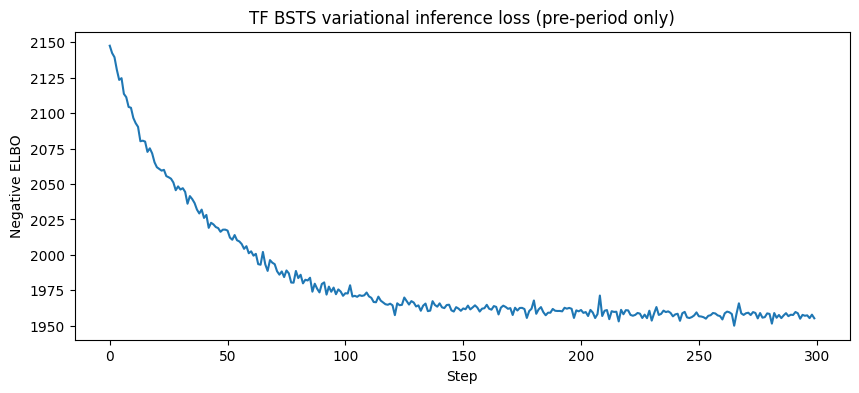

Manual BSTS fitting complete.


In [ ]:
# Fit the manual Bayesian model with variational inference
# Interpretation:
# - The loss should generally fall and then stabilise.
# - A noisy but downward trend is normal.
# - This tells us the surrogate posterior is learning a reasonable approximation
#   to the latent-state posterior over the pre-period.
surrogate_posterior = tfp.sts.build_factored_surrogate_posterior(model=manual_model)

num_variational_steps = 300

losses = tfp.vi.fit_surrogate_posterior(
    target_log_prob_fn=manual_model.joint_log_prob(observed_time_series=observed_pre),
    surrogate_posterior=surrogate_posterior,
    optimizer=tf.optimizers.Adam(learning_rate=0.05),
    num_steps=num_variational_steps,
)

plt.figure(figsize=(10, 4))
plt.plot(losses)
plt.title("TF BSTS variational inference loss (pre-period only)")
plt.xlabel("Step")
plt.ylabel("Negative ELBO")
plt.show()

parameter_samples = surrogate_posterior.sample(100)
print("Manual BSTS fitting complete.")

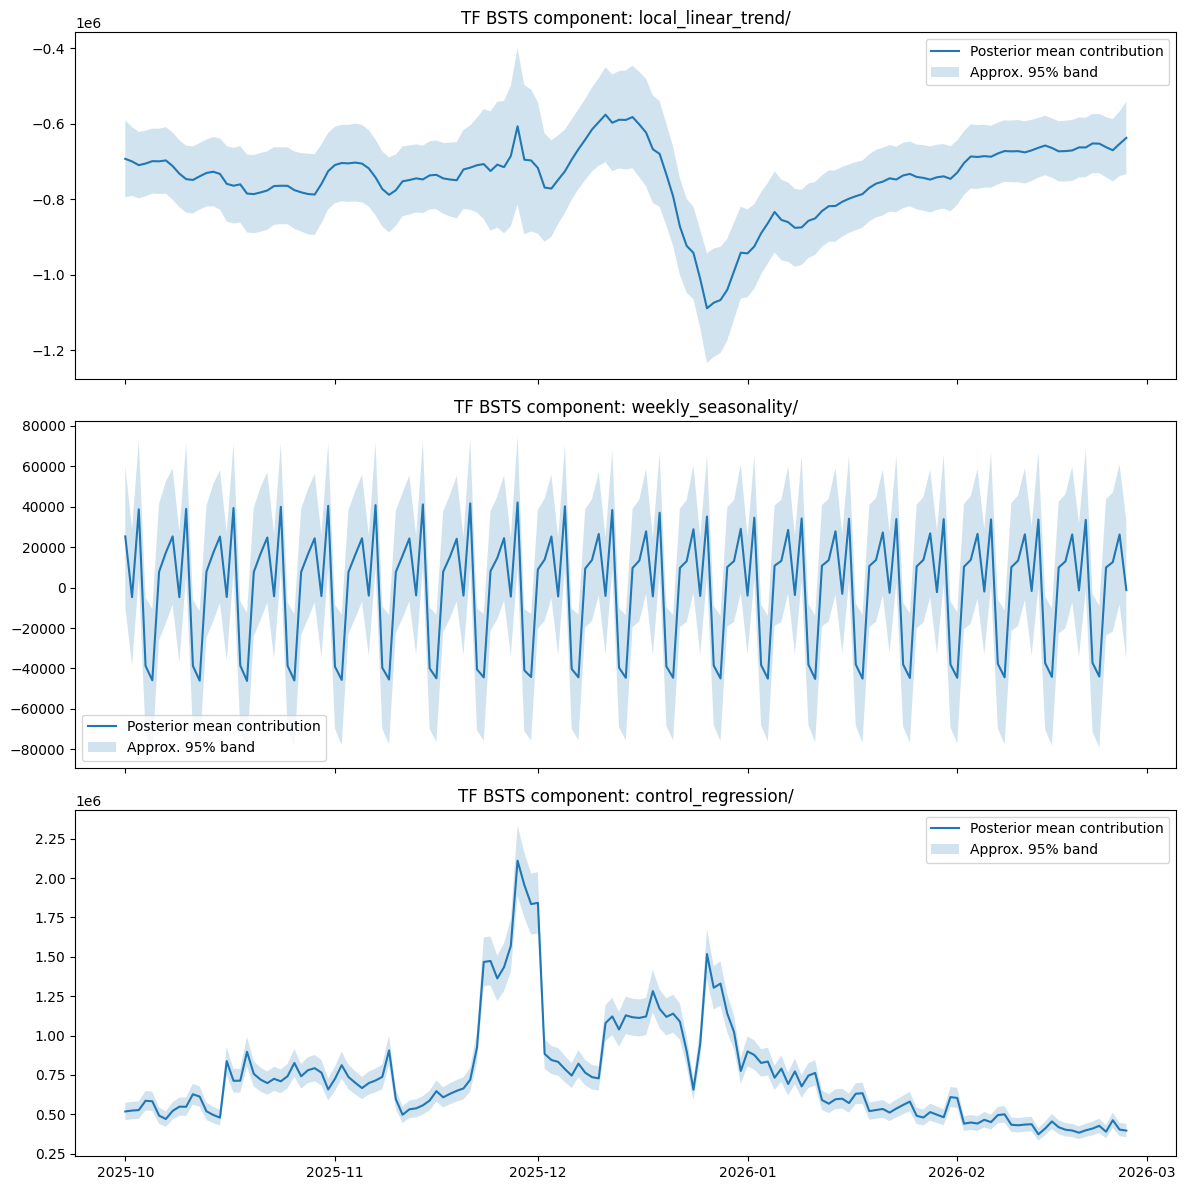

How to read this section:
- If weekly_seasonality is large and stable, weekday effects matter a lot.
- If control_regression is material, the covariates are helping explain revenue.
- If local_linear_trend dominates, the series is being driven more by underlying drift than by controls.
- This is a diagnostic decomposition, not the final causal effect estimate.


In [ ]:
# Component decomposition on the pre-period
# Interpretation:
# - local_linear_trend: the baseline level/slope the model needed to explain revenue
# - weekly_seasonality: recurring day-of-week pattern
# - control_regression: contribution from the external covariates
# Wide intervals imply uncertainty; tight intervals imply the component is estimated more confidently.
component_dists = tfp.sts.decompose_by_component(
    manual_model,
    observed_time_series=observed_pre,
    parameter_samples=parameter_samples,
)

num_components = len(component_dists)
fig, axes = plt.subplots(num_components, 1, figsize=(12, 4 * num_components), sharex=True)

if num_components == 1:
    axes = [axes]

for i, (component, component_dist) in enumerate(component_dists.items()):
    component_mean = component_dist.mean().numpy().squeeze()
    component_stddev = component_dist.stddev().numpy().squeeze()
    clean_name = component.name if hasattr(component, "name") else component.__class__.__name__

    axes[i].plot(pre_data.index, component_mean, label="Posterior mean contribution")
    axes[i].fill_between(
        pre_data.index,
        component_mean - 2 * component_stddev,
        component_mean + 2 * component_stddev,
        alpha=0.2,
        label="Approx. 95% band"
    )
    axes[i].set_title(f"TF BSTS component: {clean_name}")
    axes[i].legend()

plt.tight_layout()
plt.show()

print(
    "How to read this section:\n"
    "- If weekly_seasonality is large and stable, weekday effects matter a lot.\n"
    "- If control_regression is material, the covariates are helping explain revenue.\n"
    "- If local_linear_trend dominates, the series is being driven more by underlying drift than by controls.\n"
    "- This is a diagnostic decomposition, not the final causal effect estimate."
)